# Importing packages and data

In [ ]:
!pip install sktime "numpy<2.0" pmdarima tensorflow

In [ ]:
!pip install keras-tuner --upgrade

  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.8-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)


In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

# Statsmodels / Time Series
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import statsmodels.graphics.api as smgraphics

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller as adf, acf
from statsmodels.tsa.seasonal import STL,seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARIMA
import pmdarima as pm
from pmdarima.arima import auto_arima
from sktime.forecasting.arima import AutoARIMA

# sktime
import sktime
from sktime.forecasting.compose import (
    TransformedTargetForecaster,
    make_reduction
)
from sktime.forecasting.model_selection import (
    ExpandingWindowSplitter,
    ForecastingGridSearchCV
)
from sktime.performance_metrics.forecasting import (
    MeanAbsolutePercentageError
)
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.transformations.series.detrend import (
    Deseasonalizer,
    Detrender
)

# Scikit-learn
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid

# XGBoost
from xgboost import XGBRegressor
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# TensorFlow / Keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

# Hyperparameter tuning
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

# Other utilities
from scipy.stats import boxcox
from datetime import datetime, timedelta
from pandas.plotting import register_matplotlib_converters
import warnings

register_matplotlib_converters()

# Suppress warnings
warnings.filterwarnings("ignore")

# Default plot size
plt.rcParams["figure.figsize"] = (10, 5)

/tmp/ipykernel_2918/1732807806.py:69: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


# Data Loading & Exploration

In [ ]:
isbn_file = pd.read_excel("/content/ISBN List.xlsx",sheet_name=None)

timeline_file = pd.read_excel("/content/UK Weekly Trended Timeline from 200101_202429.xlsx",sheet_name=None)

In [ ]:
print(isbn_file.keys())
print(timeline_file.keys())

dict_keys(['F - Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])
dict_keys(['F Adult Fiction', 'S Adult Non-Fiction Specialist', 'T Adult Non-Fiction Trade', "Y Children's, YA & Educational"])


In [ ]:
for sheet_name, df in isbn_file.items():
    print("\nISBN FILE:", sheet_name)
    print(df.head())
    print(df.columns)

for sheet_name, df in timeline_file.items():
    print("\nTIMELINE FILE:", sheet_name)
    print(df.head())
    print(df.columns)


ISBN FILE: F - Adult Fiction
            ISBN                                              Title  \
0  9780330375252                Bridget Jones's Diary (Film Tie-in)   
1  9780140276336                                        White Teeth   
2  9780006512134                                        Man and Boy   
3  9780099280255                                       Brethren,The   
4  9780552998727  Marrying The Mistress:an irresistible and grip...   

             Author                   Imprint    Publisher Group    RRP  \
0   Fielding, Helen                   Picador  Pan Macmillan Grp   8.99   
1      Smith, Zadie         Penguin Books Ltd        Penguin Grp   9.99   
2     Parsons, Tony  HarperCollins Publishers  HarperCollins Grp   8.99   
3     Grisham, John               Arrow Books   Random House Grp   6.99   
4  Trollope, Joanna                Black Swan     Transworld Grp  10.99   

     Binding Publication Date                     Product Class  \
0  Paperback       2001-0

# Conducting initial data investigation

In [ ]:
# Combine all sheets and retain their category
timeline_df = pd.concat(
    [
        sheet.assign(Category=name)
        for name, sheet in timeline_file.items()
    ],
    ignore_index=True
)

isbn_df = pd.concat(
    [
        sheet.assign(Category=name)
        for name, sheet in isbn_file.items()
    ],
    ignore_index=True
)

In [ ]:
# Make column names easier to work with
timeline_df.columns = timeline_df.columns.str.replace(" ", "_")
isbn_df.columns = isbn_df.columns.str.replace(" ", "_")

In [ ]:
# Convert ISBN to string
timeline_df["ISBN"] = timeline_df["ISBN"].astype(str)
isbn_df["ISBN"] = isbn_df["ISBN"].astype(str)

ISBN was converted from an integer to a string because it represents a unique identifier rather than a numerical measurement.

In [ ]:
# Ensure dates are datetime
timeline_df["End_Date"] = pd.to_datetime(
    timeline_df["End_Date"]
)

isbn_df["Publication_Date"] = pd.to_datetime(
    isbn_df["Publication_Date"]
)

End_Date was confirmed as a datetime variable, making the data suitable for time-series operations such as chronological sorting, filtering and resampling.

In [ ]:
print("isbn shape :\n")
print(isbn_df.shape)
print("\ntimeline shape :\n")
print(timeline_df.shape)

print("\nisbn table :\n")
display(isbn_df.head())
print("\ntimeline table :\n")
display(timeline_df.head())

isbn shape :

(500, 11)

timeline shape :

(227224, 14)

isbn table :



,ISBN,Title,Author,Imprint,Publisher_Group,RRP,Binding,Publication_Date,Product_Class,Country_of_Publication,Category
0,9780330375252,Bridget Jones's Diary (Film Tie-in),"Fielding, Helen",Picador,Pan Macmillan Grp,8.99,Paperback,2001-03-23,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
1,9780140276336,White Teeth,"Smith, Zadie",Penguin Books Ltd,Penguin Grp,9.99,Paperback,2001-01-25,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
2,9780006512134,Man and Boy,"Parsons, Tony",HarperCollins Publishers,HarperCollins Grp,8.99,Paperback,2000-03-06,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction
3,9780099280255,"Brethren,The","Grisham, John",Arrow Books,Random House Grp,6.99,Paperback,2000-12-27,"F2.1 Crime, Thriller & Adventure",United Kingdom,F - Adult Fiction
4,9780552998727,Marrying The Mistress:an irresistible and grip...,"Trollope, Joanna",Black Swan,Transworld Grp,10.99,Paperback,2001-02-01,F1.1 General & Literary Fiction,United Kingdom,F - Adult Fiction



timeline table :



,ISBN,Title,Author,Interval,End_Date,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
0,9780002261821,One For My Baby,"Parsons, Tony",200513,2005-04-02,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
1,9780002261821,One For My Baby,"Parsons, Tony",200503,2005-01-22,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
2,9780002261821,One For My Baby,"Parsons, Tony",200422,2004-05-29,1,11.19,11.19,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
3,9780002261821,One For My Baby,"Parsons, Tony",200415,2004-04-10,2,27.18,13.59,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction
4,9780002261821,One For My Baby,"Parsons, Tony",200404,2004-01-24,2,22.48,11.24,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


In [ ]:
print("\nisbn types :\n")
print(isbn_df.dtypes)
print("\ntimeline types :\n")
print(timeline_df.dtypes)


isbn types :

ISBN                              object
Title                             object
Author                            object
Imprint                           object
Publisher_Group                   object
RRP                              float64
Binding                           object
Publication_Date          datetime64[ns]
Product_Class                     object
Country_of_Publication            object
Category                          object
dtype: object

timeline types :

ISBN                       object
Title                      object
Author                     object
Interval                    int64
End_Date           datetime64[ns]
Volume                      int64
Value                     float64
ASP                       float64
RRP                       float64
Binding                    object
Imprint                    object
Publisher_Group            object
Product_Class              object
Category                   object
dtype: object


In [ ]:
print("Unique ISBNs in ISBN file:", isbn_df["ISBN"].nunique())
print("Unique ISBNs in timeline file:", timeline_df["ISBN"].nunique())

print("Earliest date:", timeline_df["End_Date"].min())
print("Latest date:", timeline_df["End_Date"].max())

Unique ISBNs in ISBN file: 500
Unique ISBNs in timeline file: 500
Earliest date: 2001-01-06 00:00:00
Latest date: 2024-07-20 00:00:00


* The ISBN dataset contains 500 unique books, while the weekly timeline dataset contains 227,224 sales records. Both datasets contain 500 unique ISBNs, indicating that sales information is available for all books included in the ISBN dataset.
* The weekly sales dataset covers the period from January 2001 to July 2024, providing more than 23 years of historical sales information. This long time span should allow both long-term trends and recurring seasonal patterns to be investigated.

In [ ]:
# Sort by ISBN and date
timeline_df = timeline_df.sort_values(["ISBN", "End_Date"])

# Resample weekly sales for each ISBN
weekly_df = (timeline_df.set_index("End_Date").groupby("ISBN")["Volume"].resample("W-SAT").sum().fillna(0).reset_index())

Weekly observations were resampled using W-SAT, as the original Nielsen End_Date observations are aligned to Saturdays. This preserves the weekly date convention of the source data while filling weeks with no recorded sales.

In [ ]:
print(weekly_df.shape)
display(weekly_df.head(10))

print("Earliest date:", weekly_df["End_Date"].min())
print("Latest date:", weekly_df["End_Date"].max())

print(weekly_df.dtypes)

(382871, 3)


,ISBN,End_Date,Volume
0,9780001713031,2001-01-06,522
1,9780001713031,2001-01-13,379
2,9780001713031,2001-01-20,393
3,9780001713031,2001-01-27,369
4,9780001713031,2001-02-03,423
5,9780001713031,2001-02-10,435
6,9780001713031,2001-02-17,562
7,9780001713031,2001-02-24,843
8,9780001713031,2001-03-03,582
9,9780001713031,2001-03-10,668


Earliest date: 2001-01-06 00:00:00
Latest date: 2024-07-20 00:00:00
ISBN                object
End_Date    datetime64[ns]
Volume               int64
dtype: object


In [ ]:
print("Number of zero-sales weeks:", (weekly_df["Volume"] == 0).sum())

Number of zero-sales weeks: 155990


After resampling, the dataset increased from 227,224 to 382,871 weekly observations. The final resampled dataset contains 155,990 observations with Volume = 0, consisting mainly of weeks introduced to represent previously missing sales periods, together with any zero-volume observations already present in the source data.

In [ ]:
recent_sales = timeline_df[timeline_df["End_Date"] > "2024-07-01"]

recent_isbns = recent_sales["ISBN"].unique()

print("Number of ISBNs:", len(recent_isbns))
print(recent_isbns)

Number of ISBNs: 61
['9780006512134' '9780006514091' '9780006514213' '9780006531203'
 '9780006550433' '9780006647553' '9780007101887' '9780091816971'
 '9780091867775' '9780099244721' '9780099285823' '9780099286387'
 '9780099286578' '9780099422587' '9780099428558' '9780099771517'
 '9780140259506' '9780140275421' '9780140276336' '9780140276619'
 '9780140281293' '9780140285215' '9780140294231' '9780140295962'
 '9780224060875' '9780241003008' '9780261103252' '9780330355667'
 '9780340696767' '9780340766057' '9780340786055' '9780349112763'
 '9780349113609' '9780349114033' '9780440864141' '9780440864554'
 '9780552145053' '9780552145060' '9780552145954' '9780552997034'
 '9780552997348' '9780552998000' '9780552998444' '9780552998482'
 '9780552998727' '9780593048153' '9780719559792' '9780722532935'
 '9780744523232' '9780747268161' '9780749395698' '9780749397548'
 '9780752844299' '9780752846576' '9781841150437' '9781841460307'
 '9781841460406' '9781841461502' '9781841462301' '9781841462400'
 '978

A total of 61 ISBNs have recorded sales observations after 1 July 2024. These titles will be retained for further visual investigation of their long-term sales patterns.

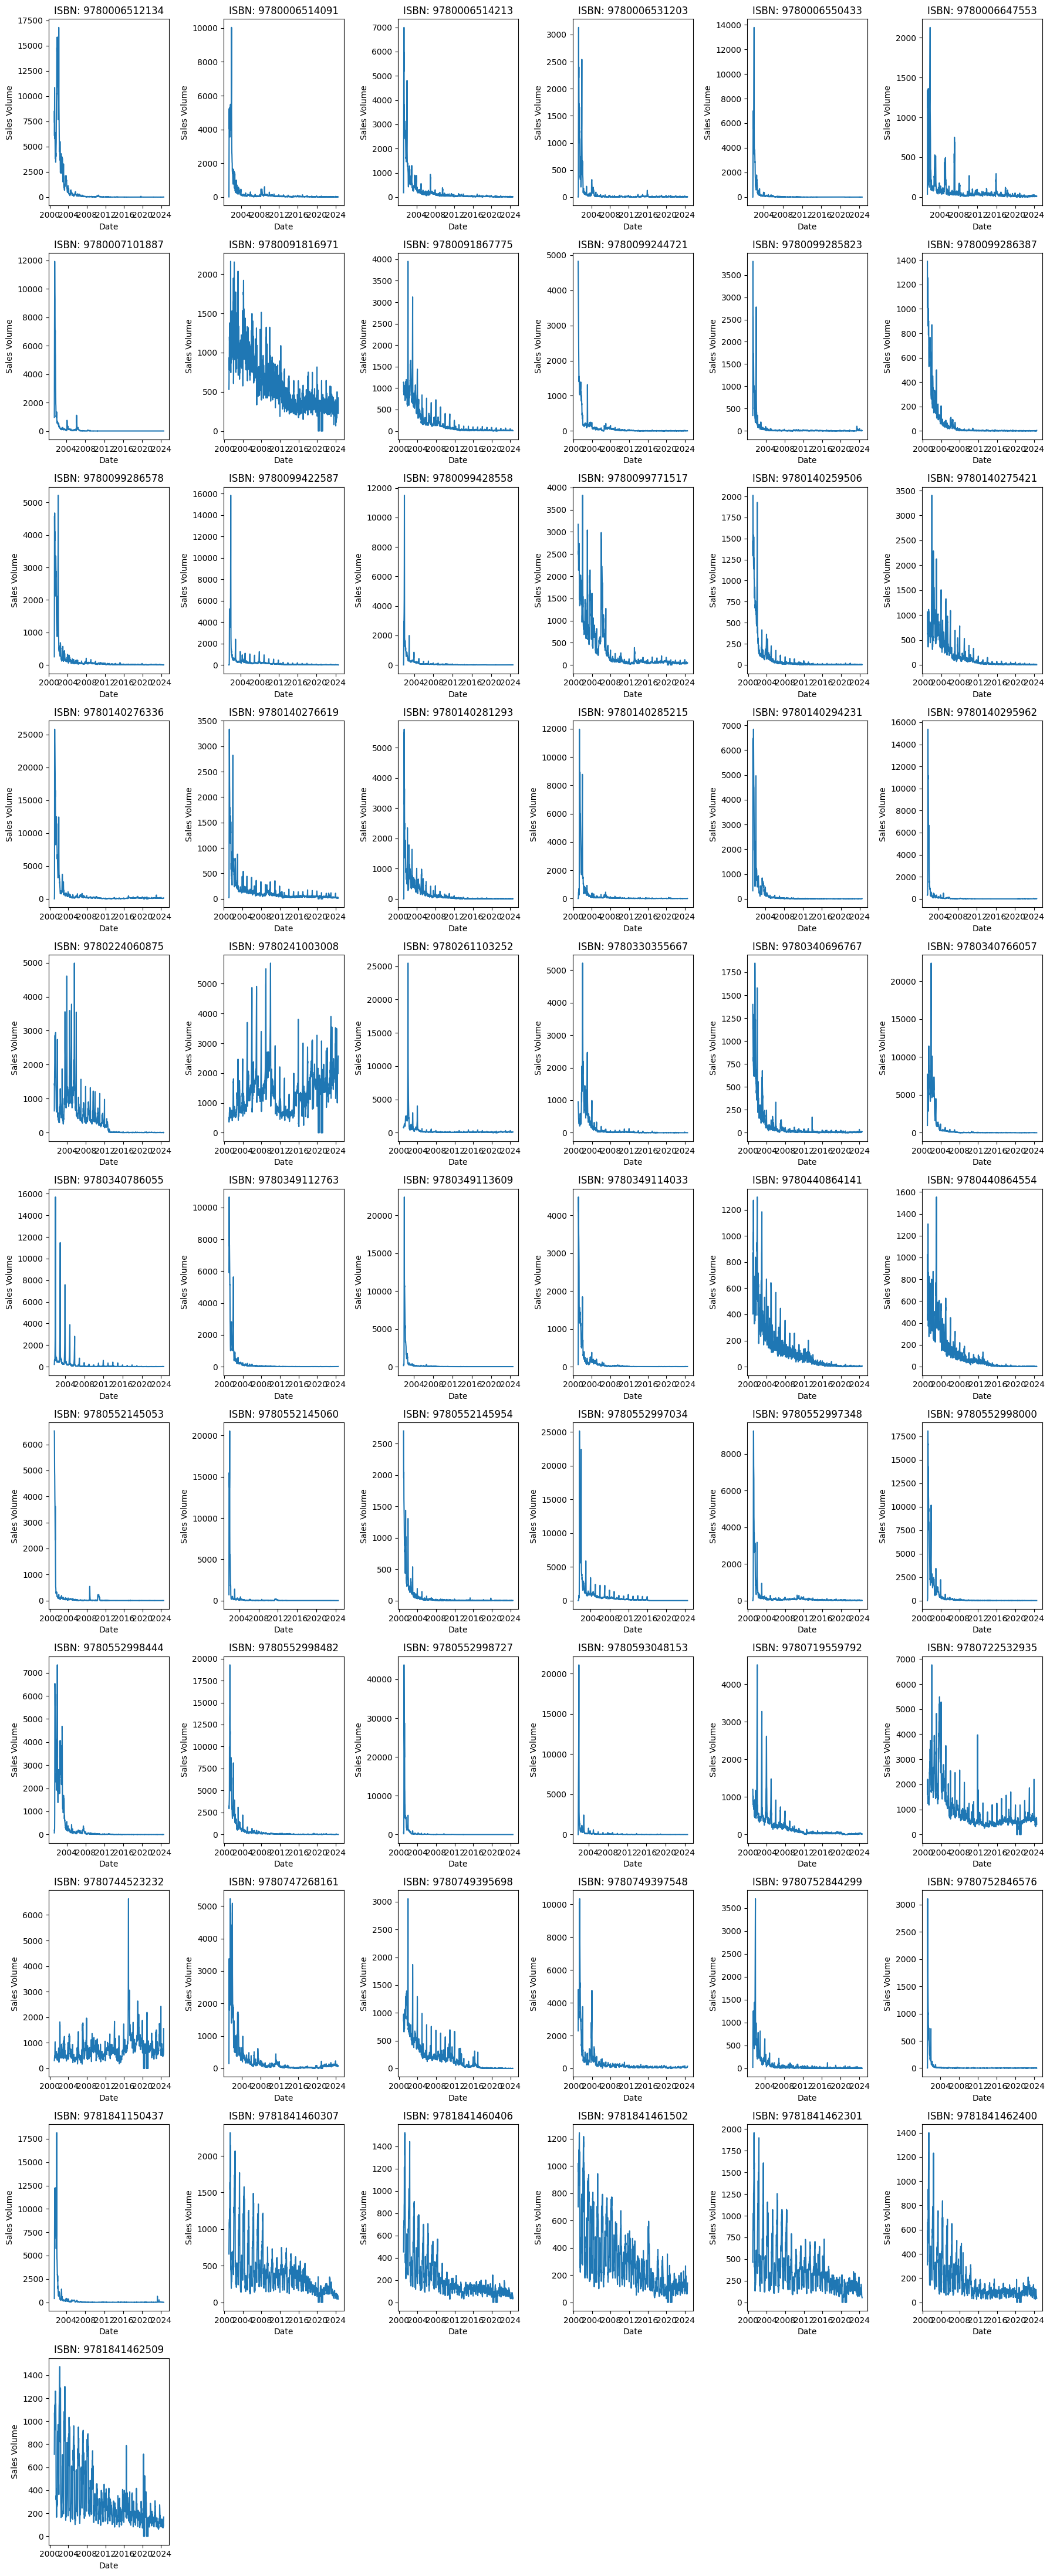

In [ ]:
selected_weekly = weekly_df[weekly_df["ISBN"].isin(recent_isbns)]

num_plots = len(recent_isbns)
cols = 6
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows,cols,figsize=(18, 4 * rows))

axes = axes.flatten()

for i, isbn in enumerate(recent_isbns):
    book_data = selected_weekly[selected_weekly["ISBN"] == isbn]

    axes[i].plot(
        book_data["End_Date"],
        book_data["Volume"]
    )

    axes[i].set_title(f"ISBN: {isbn}")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Sales Volume")

# Remove empty subplot spaces
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Visual inspection of the selected ISBNs shows considerable variation between titles, although several common patterns are visible. Many books experience their highest and most volatile sales during the earlier part of the observed period, often with one or more substantial peaks followed by a gradual decline. Some titles decline rapidly to relatively low sales levels, while others maintain more consistent sales over a longer period. Several series also contain recurring peaks that may suggest seasonal demand, although further decomposition and autocorrelation analysis would be needed to confirm this.

When comparing approximately years 1–12 with years 12–24, the overall nature of the sales patterns does not completely change, but the magnitude and variability of sales generally decrease. The first 1–12 years tend to contain higher sales volumes, larger fluctuations and more pronounced peaks. During years 12–24, many titles show lower and more stable sales, although some continue to display persistent or recurring demand.

A possible explanation is the typical lifecycle of a book: demand may be strongest following publication and then decline as the title matures and newer publications enter the market. Titles that continue selling over a much longer period may have lasting cultural, educational or literary relevance. Isolated later peaks could potentially reflect renewed publicity, adaptations, promotions or other external events; however, these causes cannot be confirmed from the sales data alone.

In [ ]:
alchemist_isbns = isbn_df[isbn_df["Title"].str.contains("alchemist", case=False, na=False)]["ISBN"].unique()

caterpillar_isbns = isbn_df[isbn_df["Title"].str.contains("caterpillar", case=False, na=False)]["ISBN"].unique()

print("The Alchemist ISBNs:")
print(alchemist_isbns)

print("\nThe Very Hungry Caterpillar ISBNs:")
print(caterpillar_isbns)

The Alchemist ISBNs:
['9780722532935']

The Very Hungry Caterpillar ISBNs:
['9780241003008' '9780140500875']


In [ ]:
post2012_weekly = weekly_df[weekly_df["End_Date"] > "2012-01-01"]

print("The Very Hungry Caterpillar:\n")
for isbn in caterpillar_isbns:
    total_volume = post2012_weekly[post2012_weekly["ISBN"] == isbn]["Volume"].sum()
    print(isbn, total_volume)

The Very Hungry Caterpillar:

9780241003008 883534
9780140500875 2


In [ ]:
alchemist_volume = post2012_weekly[post2012_weekly["ISBN"] == "9780722532935"]["Volume"].sum()
print("The Alchemist:", alchemist_volume)

The Alchemist: 345907


Two ISBNs were identified for The Very Hungry Caterpillar. However, ISBN 9780241003008 recorded 883,534 units after 2012, while ISBN 9780140500875 recorded only 2 units. Therefore, ISBN 9780241003008 was selected for further time-series analysis. The Alchemist was represented by ISBN 9780722532935, with 345,907 units sold after 2012.

In [ ]:
selected_isbns = [
    "9780241003008",  # The Very Hungry Caterpillar
    "9780722532935"   # The Alchemist
]

books_df = weekly_df[
    (weekly_df["ISBN"].isin(selected_isbns)) &
    (weekly_df["End_Date"] > "2012-01-01")
].copy()

In [ ]:
print(books_df.shape)

print(books_df.groupby("ISBN")["Volume"].agg(["count", "sum", "min", "max"]))

(1310, 3)
               count     sum  min   max
ISBN                                   
9780241003008    655  883534    0  3905
9780722532935    655  345907    0  2201


In [ ]:
print(books_df.groupby("ISBN")["End_Date"].agg(["min", "max"]))

                     min        max
ISBN                               
9780241003008 2012-01-07 2024-07-20
9780722532935 2012-01-07 2024-07-20


Both selected books contain 655 weekly observations from January 2012 to July 2024, providing consistent and equally sized time series for further analysis. The Very Hungry Caterpillar recorded a considerably higher total sales volume than The Alchemist during this period, with 883,534 units compared with 345,907 units. Both series include zero-sales weeks introduced during the weekly resampling process.

In [ ]:
book_names = {
    "9780241003008": "The Very Hungry Caterpillar",
    "9780722532935": "The Alchemist"
}

# Check for gaps longer than one week in the original sales data
for isbn, title in book_names.items():

    check = (timeline_df[timeline_df["ISBN"] == isbn].sort_values("End_Date").copy())
    check["gap_days"] = check["End_Date"].diff().dt.days
    print(f"\n{title}")

    print(check.loc[check["gap_days"] > 7,["End_Date", "gap_days", "Volume"]].tail(15))


The Very Hungry Caterpillar
         End_Date  gap_days  Volume
176716 2020-06-20      91.0    1849
176695 2020-12-12      35.0    3078
176692 2021-03-20      84.0    2013

The Alchemist
        End_Date  gap_days  Volume
58201 2020-06-20      91.0     659
58180 2020-12-12      35.0     781
58177 2021-03-20      84.0     523


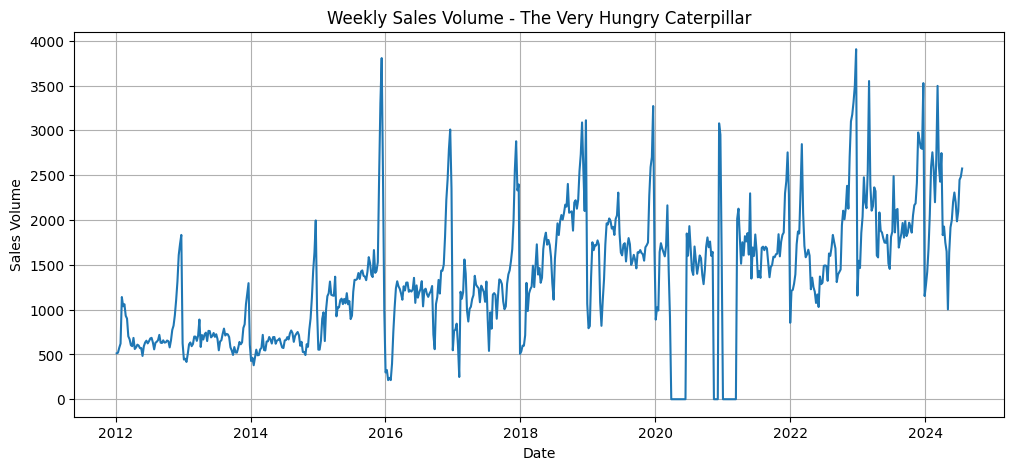

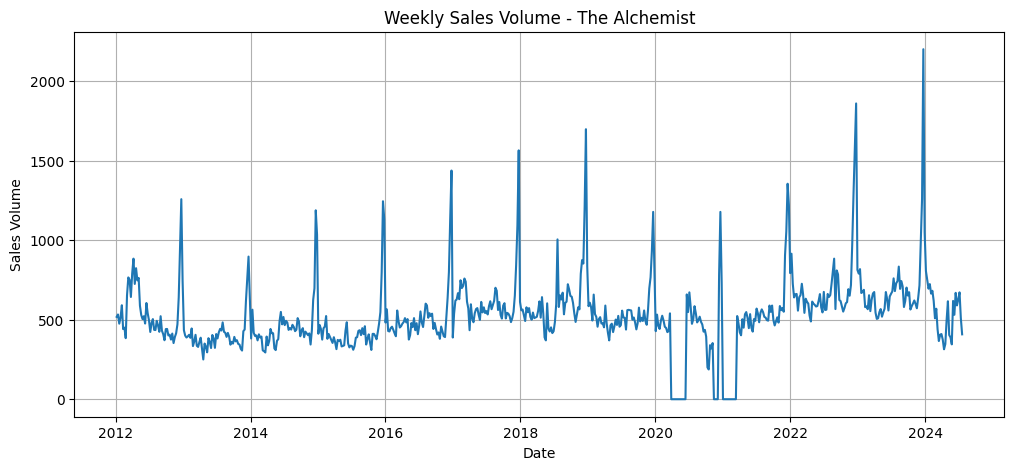

In [ ]:
for isbn, title in book_names.items():
    book_data = books_df[books_df["ISBN"] == isbn]

    plt.figure(figsize=(12, 5))
    plt.plot(book_data["End_Date"],book_data["Volume"])

    plt.title(f"Weekly Sales Volume - {title}")
    plt.xlabel("Date")
    plt.ylabel("Sales Volume")
    plt.grid(True)
    plt.show()

The weekly sales plots show higher and more variable sales for The Very Hungry Caterpillar, while The Alchemist has lower overall sales but also displays recurring peaks. Both series contain zero-sales periods around 2020–2021, corresponding to gaps of 91, 35 and 84 days in the original data. These zeros were introduced during weekly resampling and should therefore be treated as missing-data effects rather than confirmed zero demand. Overall, the series show evidence of trend and possible seasonality, which is explored further through decomposition and autocorrelation analysis.

# Classical techniques

In [ ]:
def get_book_ts(data, isbn):
    """
    Extract and prepare the weekly sales time series
    for a selected ISBN.
    """
    return (data[data["ISBN"] == isbn].set_index("End_Date")["Volume"].sort_index())

In [ ]:
def decompose_book(ts, title, period=52):
    """
    Perform and plot additive time-series decomposition
    for a selected ISBN.
    """
    # Additive decomposition
    decomposition = seasonal_decompose(ts,model="additive",period=period)

    # Plot decomposition
    decomposition.plot()
    plt.suptitle(f"Additive Decomposition - {title}",fontsize=14)
    plt.tight_layout()
    plt.show()

    return decomposition

In [ ]:
def plot_acf_pacf(ts, title, lags=104):

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    plot_acf(ts,lags=lags,ax=axes[0])
    axes[0].set_title(f"ACF - {title}")

    plot_pacf(ts,lags=lags,ax=axes[1],method="ywm")
    axes[1].set_title(f"PACF - {title}")

    plt.tight_layout()
    plt.show()

In [ ]:
def adf_test(ts, title):
    result = adf(ts)

    print(f"ADF Test - {title}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value:.4f}")

    if result[1] < 0.05:
        print("\nConclusion: Reject H0 - the series is stationary.")
    else:
        print("\nConclusion: Fail to reject H0 - the series may be non-stationary.")

In [ ]:
def train_test_split_ts(ts, test_size=32):
    """
    Split a time series into training data and
    the final observations used as the test set.
    """
    train = ts.iloc[:-test_size]
    test = ts.iloc[-test_size:]

    return train, test

In [ ]:
def fit_auto_arima(train, title):

    model = auto_arima(
        y=train,

        start_p=0,
        start_q=0,
        max_p=2,
        max_q=2,

        d=None,
        max_d=1,

        start_P=0,
        start_Q=0,
        max_P=1,
        max_Q=1,

        D=None,
        max_D=1,

        m=52,
        seasonal=True,

        information_criterion="aic",
        stepwise=True,

        suppress_warnings=True,
        error_action="ignore",
        trace=True,

        maxiter=25
    )

    print(f"\nBest model for {title}:")
    print(model.summary())

    return model

In [ ]:
def plot_residual_diagnostics(model, title, lags=52):
    """
    Plot residual diagnostics for a fitted ARIMA model.
    """
    residuals = pd.Series(model.resid()).dropna()
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    # Residuals over time
    axes[0].plot(residuals)
    axes[0].axhline(0, linestyle="--")
    axes[0].set_title(f"Residuals - {title}")
    axes[0].set_ylabel("Residual")

    # Residual distribution
    axes[1].hist(residuals, bins=30)
    axes[1].set_title("Distribution of Residuals")
    axes[1].set_xlabel("Residual")

    # Residual ACF
    plot_acf(residuals,lags=lags,ax=axes[2])
    axes[2].set_title("ACF of Residuals")

    plt.tight_layout()
    plt.show()

    return residuals

In [ ]:
def evaluate_forecast(test, predictions, title, model_name):

    # Convert predictions to a Series with test dates
    forecast = pd.Series(np.asarray(predictions),index=test.index)

    # Accuracy metrics
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    # MAPE - only where actual sales are not zero
    non_zero = test != 0
    mape = mean_absolute_percentage_error(test[non_zero],forecast[non_zero]) * 100

    # Plot actual vs forecast
    plt.figure(figsize=(12, 5))
    plt.plot(test.index,test,label="Actual")
    plt.plot(forecast.index,forecast,label=f"{model_name} Forecast")

    plt.title(f"{model_name} Forecast - {title}")
    plt.xlabel("Date")
    plt.ylabel("Sales Volume")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print metrics
    print(title)
    print(f"Model: {model_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    return forecast, mae, rmse, mape

In [ ]:
caterpillar_ts = get_book_ts(books_df,"9780241003008")

alchemist_ts = get_book_ts(books_df,"9780722532935")

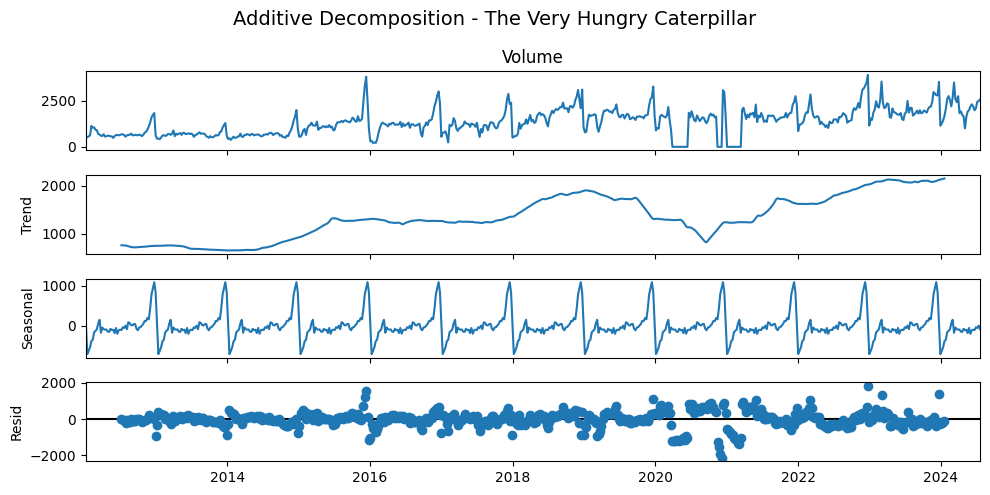

In [ ]:
caterpillar_decomp = decompose_book(caterpillar_ts,"The Very Hungry Caterpillar")

The decomposition shows an overall upward trend and a clear annual seasonal pattern repeating approximately every 52 weeks. Residuals are generally centred around zero but contain some large deviations. The unusual residuals around 2020–2021 coincide with the missing-data periods filled with zeros during resampling and should therefore be interpreted cautiously. Overall, the series exhibits both trend and strong annual seasonality.

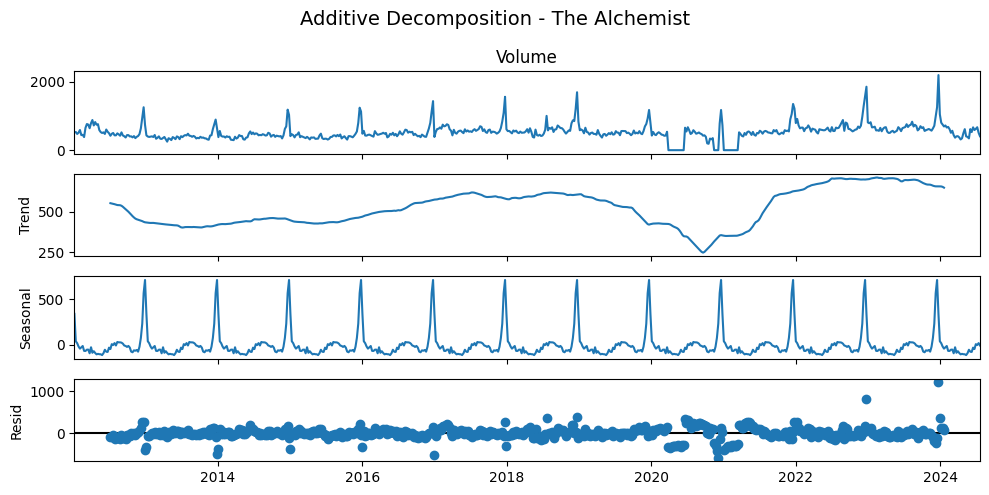

In [ ]:
alchemist_decomp = decompose_book(alchemist_ts,"The Alchemist")

The decomposition shows a changing long-term trend and a clear annual seasonal pattern repeating approximately every 52 weeks. Residuals are mostly centred around zero but contain some large deviations. The unusual residuals around 2020–2021 coincide with the missing-data periods filled with zeros during resampling and should therefore be interpreted cautiously. Overall, the series shows clear evidence of trend and annual seasonality.

## ACF & PACF

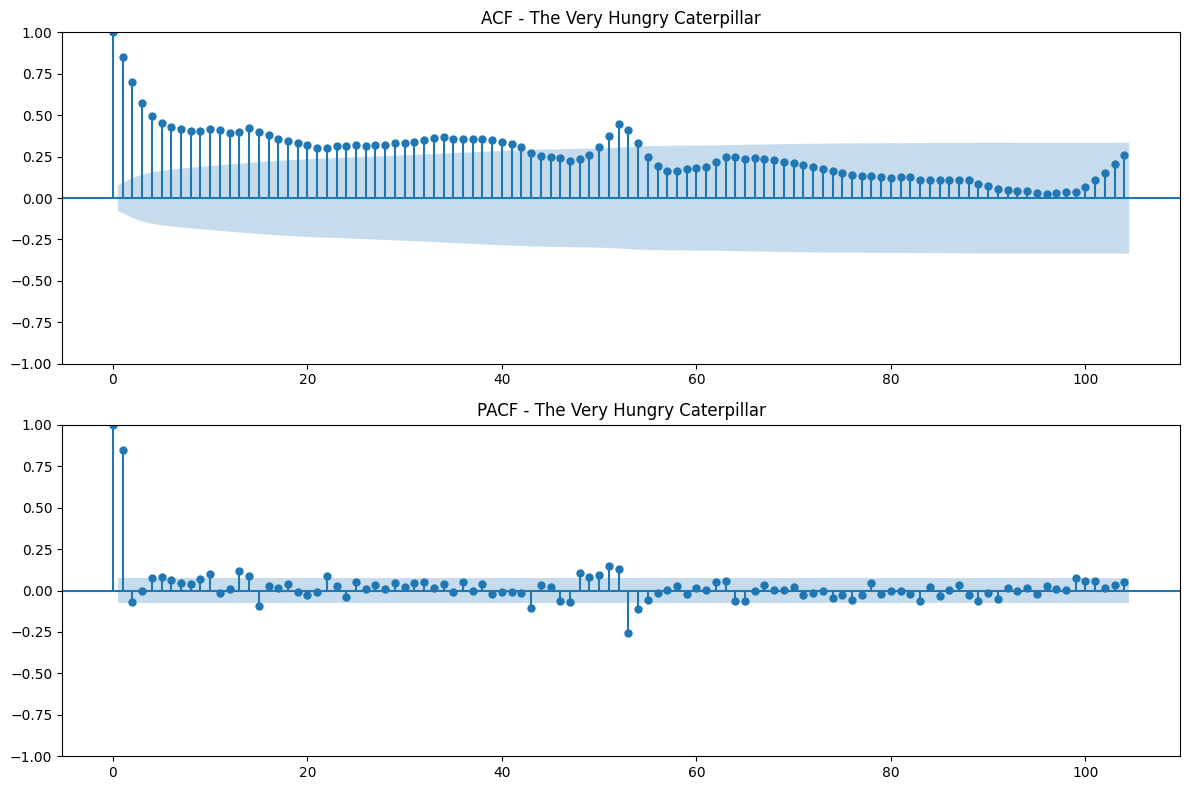

In [ ]:
plot_acf_pacf(caterpillar_ts,"The Very Hungry Caterpillar")

The ACF shows strong positive autocorrelation at the first few lags, with the correlation declining gradually rather than disappearing immediately. This indicates substantial persistence in weekly sales. A noticeable increase in autocorrelation is also observed around lag 52, with further evidence near lag 104, supporting the annual seasonal pattern identified in the decomposition. The PACF is dominated by a strong spike at lag 1, suggesting that the immediately preceding week's sales have an important direct relationship with current sales after controlling for shorter-lag effects. Additional significant spikes around the seasonal region provide further evidence of yearly dependence. Overall, the plots indicate both short-term dependence and annual seasonal structure in the sales series.

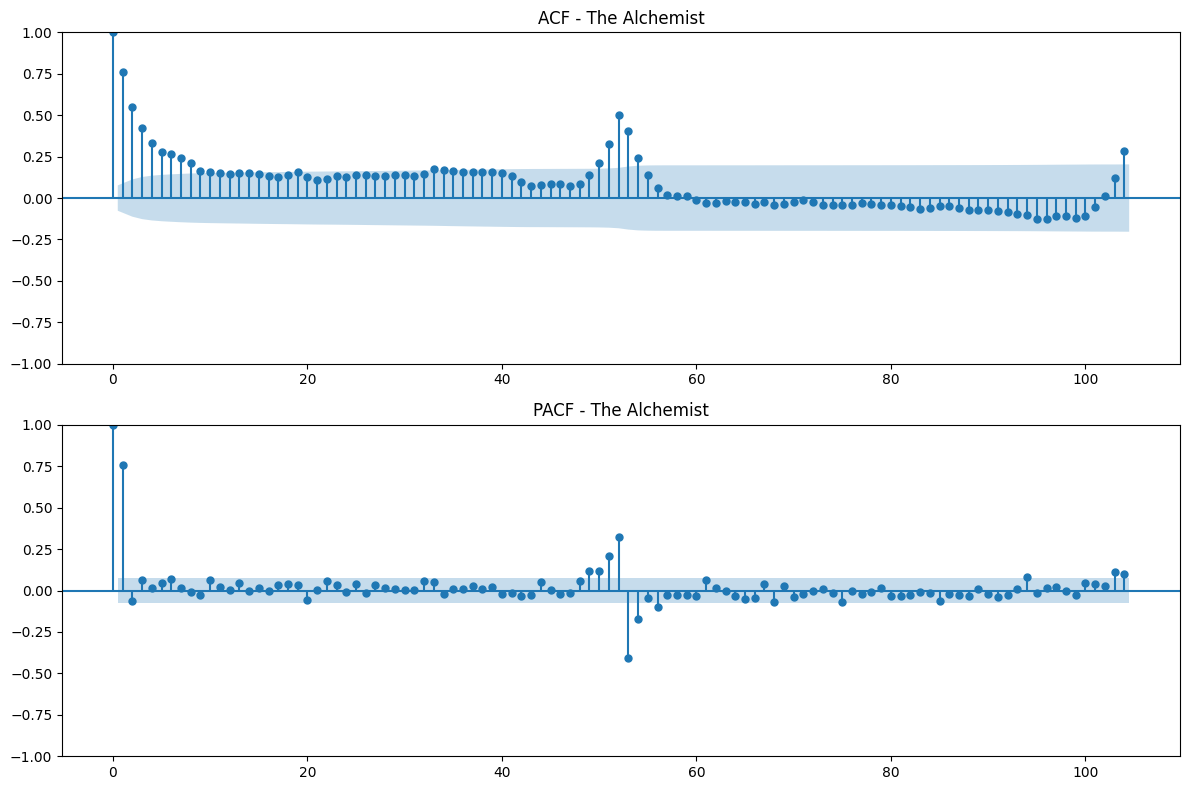

In [ ]:
plot_acf_pacf(alchemist_ts,"The Alchemist")

The ACF shows strong positive autocorrelation at the initial lags, indicating that weekly sales are closely related to recent sales observations. A pronounced increase in autocorrelation occurs around lag 52, with another increase near lag 104, providing further evidence of an annual seasonal pattern. The PACF is dominated by a strong spike at lag 1, while most intermediate lags are considerably smaller. Additional significant behaviour around the 52-week region suggests that annual seasonal dependence remains important even after accounting for shorter-lag relationships. Compared with The Very Hungry Caterpillar, the autocorrelation structure differs somewhat across the intermediate lags, although both books demonstrate clear short-term dependence and annual seasonality.

In [ ]:
adf_test(caterpillar_ts,"The Very Hungry Caterpillar")

ADF Test - The Very Hungry Caterpillar
ADF Statistic: -3.0605
p-value: 0.0296

Critical Values:
1%: -3.4406
5%: -2.8661
10%: -2.5692

Conclusion: Reject H0 - the series is stationary.


In [ ]:
adf_test(alchemist_ts,"The Alchemist")

ADF Test - The Alchemist
ADF Statistic: -8.2959
p-value: 0.0000

Critical Values:
1%: -3.4404
5%: -2.8660
10%: -2.5691

Conclusion: Reject H0 - the series is stationary.


The ADF test indicates that both weekly sales series are stationary at the 5% significance level. For The Very Hungry Caterpillar, the p-value is 0.0296, while for The Alchemist it is below 0.001. In both cases, the null hypothesis of a unit root is rejected. Therefore, there is no immediate statistical requirement for ordinary differencing solely to achieve stationarity, although seasonal differencing may still be considered later when fitting seasonal ARIMA models because both series show clear annual seasonality.

In [ ]:
caterpillar_train, caterpillar_test = train_test_split_ts(caterpillar_ts)

alchemist_train, alchemist_test = train_test_split_ts(alchemist_ts)

In [ ]:
print("The Very Hungry Caterpillar")
print("Train:", len(caterpillar_train))
print("Test:", len(caterpillar_test))
print("Train ends:", caterpillar_train.index.max())
print("Test starts:", caterpillar_test.index.min())

print("\nThe Alchemist")
print("Train:", len(alchemist_train))
print("Test:", len(alchemist_test))
print("Train ends:", alchemist_train.index.max())
print("Test starts:", alchemist_test.index.min())

The Very Hungry Caterpillar
Train: 623
Test: 32
Train ends: 2023-12-09 00:00:00
Test starts: 2023-12-16 00:00:00

The Alchemist
Train: 623
Test: 32
Train ends: 2023-12-09 00:00:00
Test starts: 2023-12-16 00:00:00


Each book contains 655 weekly observations from 2012 onward. The final 32 weeks were reserved as the test set, leaving 623 observations for model training. This ensures that the forecasting models are evaluated on unseen future data rather than on observations used during fitting.

## Auto ARIMA

In [ ]:
caterpillar_arima = fit_auto_arima(caterpillar_train,"The Very Hungry Caterpillar")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=9140.609, Time=0.16 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=9056.517, Time=9.97 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=9086.169, Time=8.93 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=9138.670, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=9142.482, Time=0.07 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=9035.189, Time=9.55 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=9086.201, Time=7.89 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=9035.799, Time=10.57 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : AIC=9033.129, Time=14.75 sec
 ARIMA(2,1,0)(0,0,1)[52] intercept   : AIC=9085.092, Time=7.43 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=9055.139, Time=11.51 sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=9140.826, Time=0.18 sec
 ARIMA(2,1,1)(1,0,1)[52] intercept   : AIC=8999.752, Time=22.50 sec
 ARIMA(2,1,1)(0,0,1)[52] intercept   : AIC=9032.248, Time=16.39 sec
 ARIMA(2,1,1)(

The stepwise Auto ARIMA search selected an ARIMA(1,1,2)(1,0,1)[52] model with an intercept. The seasonal period of 52 reflects the annual pattern identified previously in the decomposition and autocorrelation analysis. The selected model includes one non-seasonal difference (d=1) but no seasonal differencing (D=0). Although the ADF test indicated stationarity at the 5% level, Auto ARIMA selected first differencing as part of the model that minimized AIC. The best model achieved an AIC of approximately 8998.36.

In [ ]:
alchemist_arima = fit_auto_arima(alchemist_train,"The Alchemist")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=7990.293, Time=0.10 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=inf, Time=6.97 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=7838.866, Time=7.36 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=7988.309, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=7990.623, Time=0.12 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=7655.665, Time=13.30 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=7708.346, Time=7.08 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=7696.062, Time=9.49 sec
 ARIMA(1,1,1)(1,0,1)[52] intercept   : AIC=inf, Time=17.62 sec
 ARIMA(0,1,2)(1,0,1)[52] intercept   : AIC=7649.144, Time=13.68 sec
 ARIMA(0,1,2)(0,0,1)[52] intercept   : AIC=7807.908, Time=8.98 sec
 ARIMA(0,1,2)(1,0,0)[52] intercept   : AIC=7685.930, Time=12.71 sec
 ARIMA(0,1,2)(0,0,0)[52] intercept   : AIC=7955.193, Time=0.69 sec
 ARIMA(1,1,2)(1,0,1)[52] intercept   : AIC=inf, Time=16.81 sec
 ARIMA(0,1,2)(1,0,1)[52]     

The stepwise Auto ARIMA search selected an ARIMA(0,1,2)(1,0,1)[52] model with an AIC of 7635.14. The model includes first-order non-seasonal differencing, two moving-average terms, and seasonal AR and MA components with a 52-week cycle. The selected seasonal structure is consistent with the annual seasonality identified previously through decomposition and ACF/PACF analysis. The Ljung–Box result at lag 1 does not indicate significant residual autocorrelation, although the Jarque–Bera and heteroskedasticity statistics suggest that the residuals are non-normal and have non-constant variance.

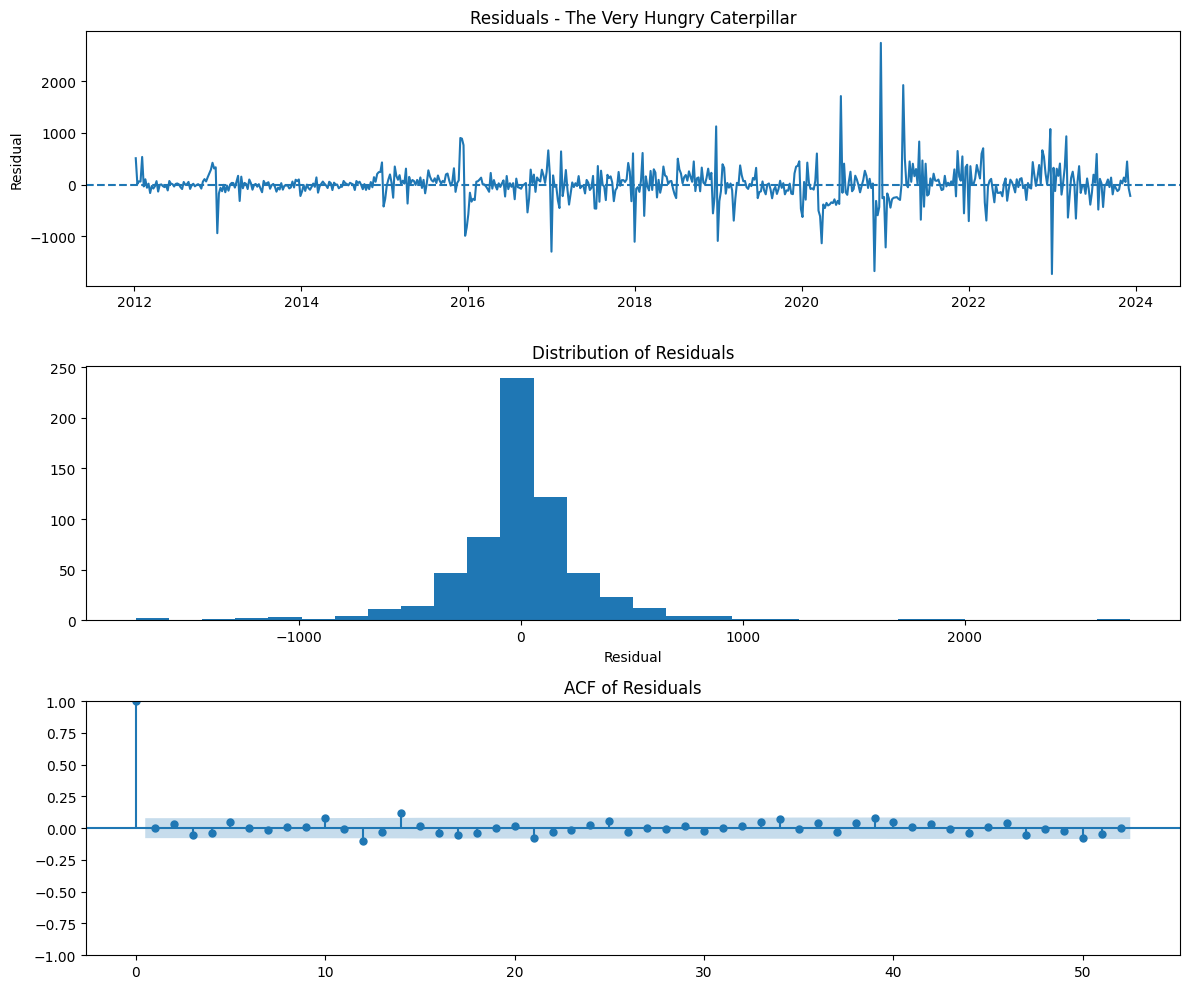

In [ ]:
caterpillar_residuals = plot_residual_diagnostics(caterpillar_arima,"The Very Hungry Caterpillar")

The SARIMA residuals are generally centred around zero with no clear remaining trend or seasonal pattern, suggesting that the model captured most of the systematic structure in the series. The residual ACF shows little remaining autocorrelation, although some isolated spikes and large residuals remain. Overall, SARIMA captures the main temporal and seasonal patterns reasonably well, but some irregular sales movements remain unexplained.

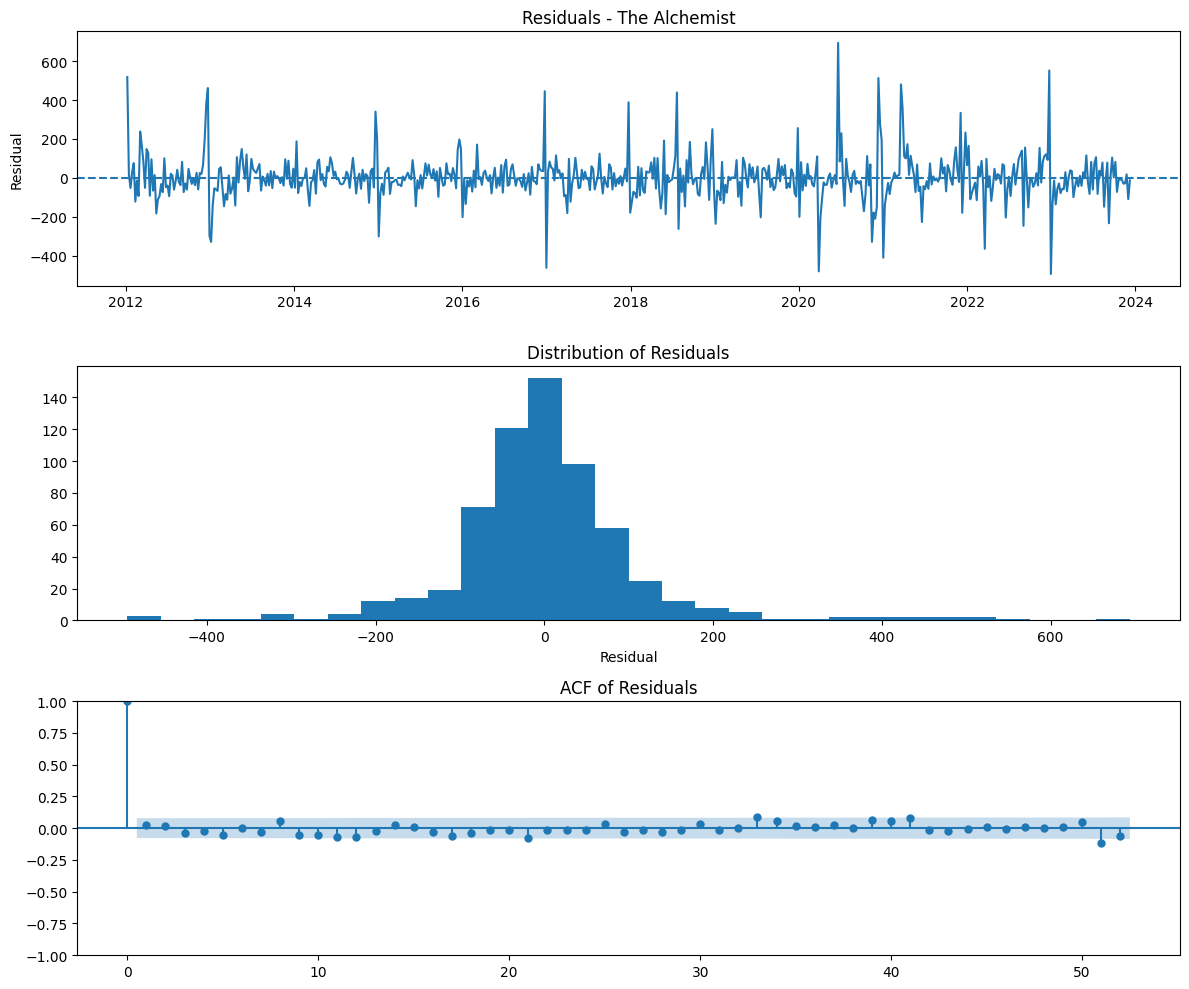

In [ ]:
alchemist_residuals = plot_residual_diagnostics(alchemist_arima,"The Alchemist")

The SARIMA residuals are generally centred around zero with no clear remaining trend or seasonality, suggesting that the model captured most of the systematic structure. The residual ACF shows little remaining autocorrelation, including at the 52-week seasonal lag. However, some large residuals remain, and the Jarque–Bera test indicates non-normality. Overall, the model provides a reasonable fit, although some irregular sales movements remain unexplained.

In [ ]:
caterpillar_sarima_pred = caterpillar_arima.predict(n_periods=len(caterpillar_test))

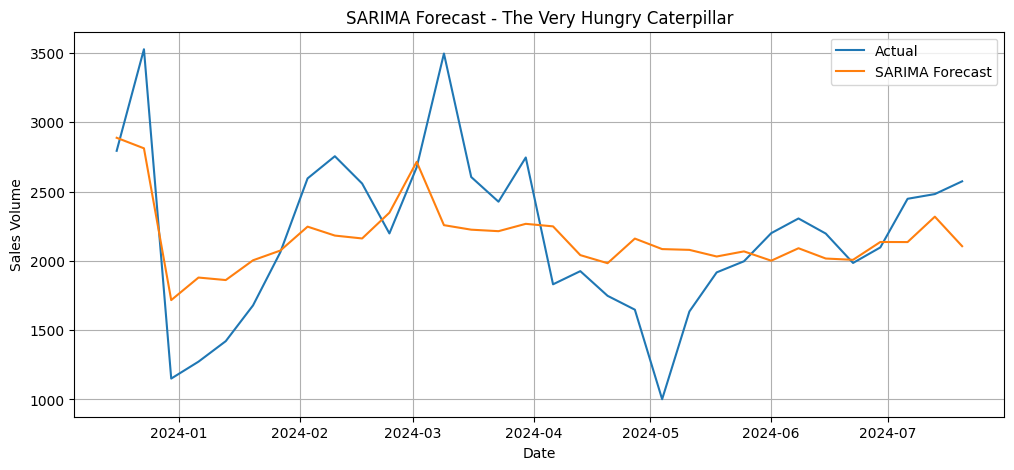

The Very Hungry Caterpillar
Model: SARIMA
MAE:  349.06
RMSE: 448.93
MAPE: 18.47%


In [ ]:
caterpillar_sarima_results = evaluate_forecast(
    caterpillar_test,
    caterpillar_sarima_pred,
    "The Very Hungry Caterpillar",
    "SARIMA"
)

The SARIMA forecast follows the general sales pattern but is smoother than the actual series and misses some sharp peaks and declines. It achieved an MAE of 349.06, RMSE of 448.93 and MAPE of 18.47%. Overall, the model provides reasonable forecast accuracy but is less effective at capturing sudden short-term fluctuations.

In [ ]:
alchemist_sarima_pred = alchemist_arima.predict(n_periods=len(alchemist_test))

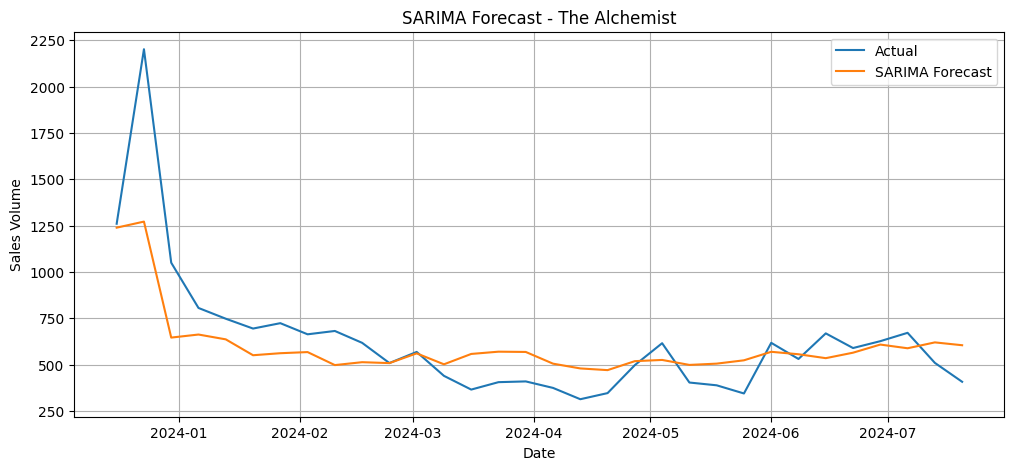

The Alchemist
Model: SARIMA
MAE:  139.02
RMSE: 213.38
MAPE: 22.92%


In [ ]:
alchemist_sarima_results = evaluate_forecast(
    alchemist_test,
    alchemist_sarima_pred,
    "The Alchemist",
    "SARIMA"
)

The SARIMA forecast follows the general sales level but is smoother than the actual series and misses some short-term fluctuations, particularly the large initial sales peak. It achieved an MAE of 139.02, RMSE of 213.38 and MAPE of 22.92%. Overall, the model provides reasonable forecast accuracy but is less effective at capturing sudden changes in weekly demand.

# Machine learning and deep learning techniques

In [ ]:
def create_lag_features(ts, window_length):
    """
    Create consecutive lag features for XGBoost.
    """
    df = pd.DataFrame({"y": ts})

    for lag in range(1, window_length + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)

    return df.dropna()

In [ ]:
def prepare_xgb_training(lagged_data, train_series):

    train_lagged = lagged_data.loc[
        lagged_data.index <= train_series.index[-1]
    ].copy()

    X_train = train_lagged.drop(columns="y")
    y_train = train_lagged["y"]

    return X_train, y_train

In [ ]:
seed = 42

def fit_xgboost(X_train, y_train):

    model = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=seed
    )

    model.fit(X_train, y_train)

    return model

In [ ]:
def recursive_forecast(history, horizon, predict_fn):
    preds = []
    history = list(history)

    for _ in range(horizon):
        pred = predict_fn(history)
        preds.append(pred)
        history.append(pred)

    return preds

In [ ]:
def predict_next_xgb(model, history, window_length):
    """
    Predict the next observation using the most recent lag window.
    """
    x_input = np.array(history[-1:-window_length-1:-1]).reshape(1, -1)

    x_input = pd.DataFrame(
        x_input,
        columns=[f"lag_{i}" for i in range(1, window_length + 1)]
    )

    return model.predict(x_input)[0]

In [ ]:
param_space = {
    "window_length": hp.choice("window_length", [14, 28, 52]),
    "max_depth": hp.quniform("max_depth", 3, 8, 1),
    "gamma": hp.uniform("gamma", 0, 5),
    "reg_alpha": hp.uniform("reg_alpha", 0, 50),
    "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.5, 1.0),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "learning_rate": hp.uniform("learning_rate", 0.02, 0.15),
    "n_estimators": hp.choice("n_estimators", [100, 200, 300])
}

In [ ]:
def xgb_hyperopt_objective(params, train_series):

    window_length = int(params["window_length"])

    # Split training series again:
    # earlier data = tuning train
    # last 32 weeks = tuning validation
    tuning_train = train_series.iloc[:-32]
    tuning_val = train_series.iloc[-32:]

    # Create lagged training data
    lagged_train = create_lag_features(tuning_train,window_length)

    X_train = lagged_train.drop(columns="y")
    y_train = lagged_train["y"]

    # XGBoost model
    model = XGBRegressor(
        n_estimators=int(params["n_estimators"]),
        max_depth=int(params["max_depth"]),
        learning_rate=params["learning_rate"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        min_child_weight=int(params["min_child_weight"]),
        colsample_bytree=params["colsample_bytree"],
        subsample=params["subsample"],
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=42
    )

    model.fit(X_train, y_train)

    # Recursive 32-week validation forecast
    predictions = recursive_forecast(
        history=tuning_train.values,
        horizon=len(tuning_val),
        predict_fn=lambda history: predict_next_xgb(
            model,
            history,
            window_length
        )
    )

    mae = mean_absolute_error(tuning_val,predictions)

    return {"loss": mae,"status": STATUS_OK}

In [ ]:
def fit_tuned_xgboost(train_series, params):

    window_length = params["window_length"]
    # Create lagged training data
    lagged = create_lag_features(train_series,window_length)
    X_train = lagged.drop(columns="y")
    y_train = lagged["y"]

    # Fit tuned XGBoost
    model = XGBRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        min_child_weight=params["min_child_weight"],
        colsample_bytree=params["colsample_bytree"],
        subsample=params["subsample"],
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

In [ ]:
lookback = 28
scaler = MinMaxScaler()

def prepare_lstm_data(train_series, lookback):
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
    X, y = [], []

    for i in range(lookback, len(train_scaled)):
        X.append(train_scaled[i-lookback:i, 0])
        y.append(train_scaled[i, 0])

    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y, scaler

In [ ]:
def fit_lstm(X_train, y_train, lookback):

    model = Sequential([LSTM(32, input_shape=(lookback, 1)),Dense(1)])
    model.compile(optimizer="adam",loss="mse")
    model.fit(X_train,y_train,epochs=12,batch_size=32,verbose=0)
    return model

In [ ]:
def predict_next_lstm(model, history, scaler, lookback):

    # Scale the current history
    history_scaled = scaler.transform(np.array(history).reshape(-1, 1)).flatten()
    # Take the most recent lookback weeks
    x_input = history_scaled[-lookback:].reshape(1, lookback, 1)
    # Predict in scaled units
    pred_scaled = model.predict(x_input,verbose=0)[0, 0]

    # Convert prediction back to original sales units
    pred = scaler.inverse_transform(np.array([[pred_scaled]]))[0, 0]

    return pred

In [ ]:
def tuned_model(hp):

    model = Sequential()
    # First LSTM layer
    model.add(
        LSTM(
            units=hp.Int(
                "input_units",
                min_value=8,
                max_value=128,
                step=8
            ),
            return_sequences=True,
            input_shape=(lookback, 1)
        )
    )

    # Additional LSTM layers
    for i in range(hp.Int("n_layers", min_value=1, max_value=3)):
        model.add(
            LSTM(
                units=hp.Int(
                    f"lstm_{i}_units",
                    min_value=8,
                    max_value=128,
                    step=8
                ),
                return_sequences=True
            )
        )

    # Final LSTM layer
    model.add(
        LSTM(
            units=hp.Int(
                "final_lstm_units",
                min_value=8,
                max_value=128,
                step=8
            )
        )
    )

    # Dropout
    model.add(
        Dropout(
            hp.Float(
                "dropout_rate",
                min_value=0.0,
                max_value=0.5,
                step=0.1
            )
        )
    )

    # Regression output
    model.add(Dense(1))
    model.compile(loss="mean_squared_error",optimizer="adam",metrics=["mae"])

    return model

In [ ]:
def tune_lstm(X_train, y_train, project_name):

    tuner = kt.RandomSearch(
        hypermodel=tuned_model,
        objective="val_loss",
        max_trials=10,
        executions_per_trial=1,
        overwrite=True,
        directory="keras_tuning",
        project_name=project_name
    )

    tuner.search(X_train,y_train,epochs=30,batch_size=32,validation_split=0.2,verbose=1)
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = tuner.get_best_models(num_models=1)[0]

    return tuner, best_hp, best_model

## XGBoost

In [ ]:
window_length = 28

caterpillar_lagged = create_lag_features(caterpillar_ts,window_length)
alchemist_lagged = create_lag_features(alchemist_ts,window_length)

In [ ]:
X_train_cat, y_train_cat = prepare_xgb_training(caterpillar_lagged,caterpillar_train)

X_train_alc, y_train_alc = prepare_xgb_training(alchemist_lagged,alchemist_train)

In [ ]:
print("Caterpillar")
print(X_train_cat.shape)
print(y_train_cat.size)

print("\nAlchemist")
print(X_train_alc.shape)
print(y_train_alc.size)

Caterpillar
(595, 28)
595

Alchemist
(595, 28)
595


In [ ]:
caterpillar_xgb = fit_xgboost(X_train_cat,y_train_cat)
alchemist_xgb = fit_xgboost(X_train_alc,y_train_alc)

A baseline XGBoost regressor was trained separately for each book using the previous 28 weeks of sales as predictors. The model uses 200 trees, a maximum depth of 4 and a learning rate of 0.05. Row and feature subsampling were both set to 0.8 to reduce overfitting. These initial hyperparameters provide a baseline model and will later be tuned using time-series cross-validation.

In [ ]:
caterpillar_xgb_pred = recursive_forecast(
    history=caterpillar_train.values,
    horizon=len(caterpillar_test),
    predict_fn=lambda history: predict_next_xgb(
        caterpillar_xgb,
        history,
        window_length
    )
)

In [ ]:
alchemist_xgb_pred = recursive_forecast(
    history=alchemist_train.values,
    horizon=len(alchemist_test),
    predict_fn=lambda history: predict_next_xgb(
        alchemist_xgb,
        history,
        window_length
    )
)

In [ ]:
print("Caterpillar predictions:", len(caterpillar_xgb_pred))
print("Alchemist predictions:", len(alchemist_xgb_pred))

print("\nFirst 5 Caterpillar predictions:")
print(caterpillar_xgb_pred[:5])

print("\nFirst 5 Alchemist predictions:")
print(alchemist_xgb_pred[:5])

Caterpillar predictions: 32
Alchemist predictions: 32

First 5 Caterpillar predictions:
[2155.9502, 1838.1936, 1815.1765, 1831.5277, 1788.8843]

First 5 Alchemist predictions:
[1144.5289, 1290.8468, 1357.3636, 908.62024, 827.9127]


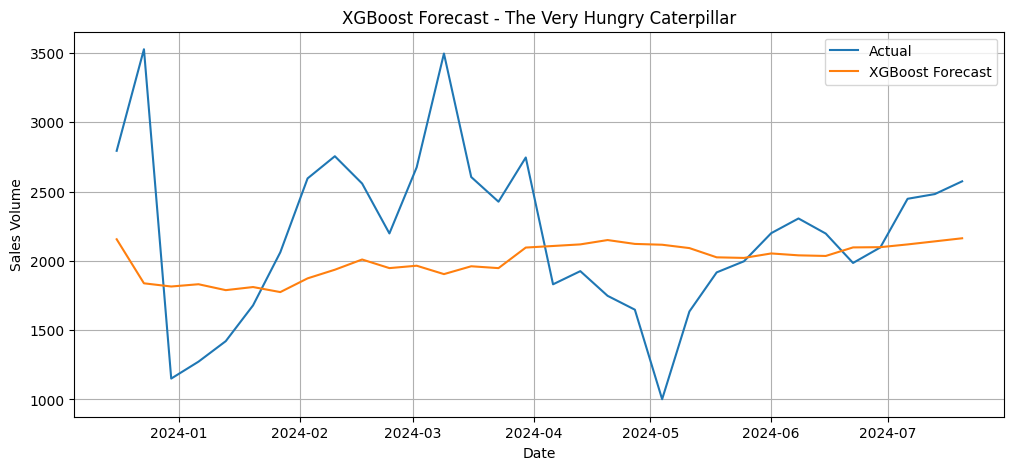

The Very Hungry Caterpillar
Model: XGBoost
MAE:  486.54
RMSE: 622.30
MAPE: 23.37%


In [ ]:
caterpillar_xgb_results = evaluate_forecast(
    caterpillar_test,
    caterpillar_xgb_pred,
    "The Very Hungry Caterpillar",
    "XGBoost"
)

The baseline XGBoost model captures the general sales level but misses some sharp fluctuations. It achieved an MAE of 486.54, RMSE of 622.30 and MAPE of 23.37%, performing worse than SARIMA. However, this model uses an initial 28-week lag window and untuned hyperparameters, so tuning may improve performance.

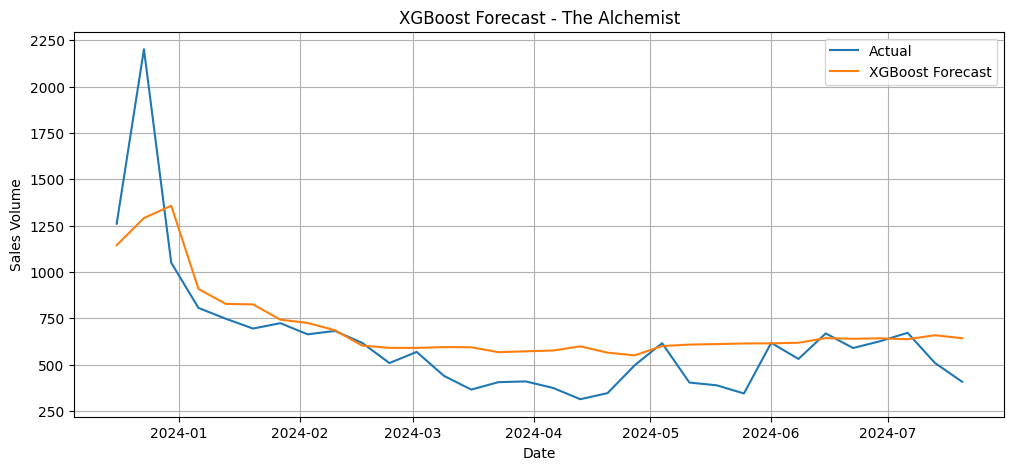

The Alchemist
Model: XGBoost
MAE:  144.53
RMSE: 219.10
MAPE: 26.99%


In [ ]:
alchemist_xgb_results = evaluate_forecast(
    alchemist_test,
    alchemist_xgb_pred,
    "The Alchemist",
    "XGBoost"
)

The baseline XGBoost model captures the general sales level but misses some sharp fluctuations. It achieved an MAE of 144.53, RMSE of 219.10 and MAPE of 26.99%, performing slightly worse than SARIMA. However, the model uses an initial 28-week lag window and untuned hyperparameters, so tuning may improve performance.

## Tuned XGBoost

In [ ]:
cat_trials = Trials()

cat_best = fmin(
    fn=lambda params: xgb_hyperopt_objective(params,caterpillar_train),
    space=param_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=cat_trials,
    rstate=np.random.default_rng(42)
)

print(cat_best)

100%|██████████| 30/30 [00:27<00:00,  1.07trial/s, best loss: 186.57049179077148]
{'colsample_bytree': 0.8601046217192846, 'gamma': 3.4606263150737337, 'learning_rate': 0.10783848969449411, 'max_depth': 5.0, 'min_child_weight': 8.0, 'n_estimators': 0, 'reg_alpha': 13.043180528930563, 'subsample': 0.8699230504257727, 'window_length': 2}


Hyperopt identified a 52-week lag window as the best-performing history length, together with 100 estimators, maximum depth 5 and a learning rate of approximately 0.108. The best validation MAE was approximately 186.57. The selection of a 52-week window is consistent with the strong annual seasonal pattern identified earlier in the time-series analysis.

In [ ]:
alc_trials = Trials()

alc_best = fmin(
    fn=lambda params: xgb_hyperopt_objective(params,alchemist_train),
    space=param_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=alc_trials,
    rstate=np.random.default_rng(42)
)

print(alc_best)

100%|██████████| 30/30 [00:24<00:00,  1.22trial/s, best loss: 62.1828727722168]
{'colsample_bytree': 0.8011265779979301, 'gamma': 2.0612335686863874, 'learning_rate': 0.0551990073261861, 'max_depth': 7.0, 'min_child_weight': 2.0, 'n_estimators': 1, 'reg_alpha': 44.6045877579082, 'subsample': 0.8684861900280383, 'window_length': 0}


Hyperopt selected a 14-week lag window, 200 estimators, maximum depth 7 and a learning rate of approximately 0.055. The best validation MAE was approximately 62.18. Unlike The Very Hungry Caterpillar, which selected a 52-week window, The Alchemist performed best using a shorter history window, suggesting that recent sales behaviour may be more useful for its XGBoost forecast than a full annual lag window.

In [ ]:
best_cat_params = {
    "window_length": 52,
    "n_estimators": 100,
    "max_depth": 5,
    "min_child_weight": 8,
    "learning_rate": 0.10783848969449411,
    "gamma": 3.4606263150737337,
    "reg_alpha": 13.043180528930563,
    "colsample_bytree": 0.8601046217192846,
    "subsample": 0.8699230504257727
}

In [ ]:
best_alc_params = {
    "window_length": 14,
    "n_estimators": 200,
    "max_depth": 7,
    "min_child_weight": 2,
    "learning_rate": 0.0551990073261861,
    "gamma": 2.0612335686863874,
    "reg_alpha": 44.6045877579082,
    "colsample_bytree": 0.8011265779979301,
    "subsample": 0.8684861900280383
}

In [ ]:
caterpillar_xgb_tuned = fit_tuned_xgboost(caterpillar_train,best_cat_params)

alchemist_xgb_tuned = fit_tuned_xgboost(alchemist_train,best_alc_params)

In [ ]:
caterpillar_xgb_tuned_pred = recursive_forecast(
    history=caterpillar_train.values,
    horizon=len(caterpillar_test),
    predict_fn=lambda history: predict_next_xgb(
        caterpillar_xgb_tuned,
        history,
        best_cat_params["window_length"]
    )
)

In [ ]:
alchemist_xgb_tuned_pred = recursive_forecast(
    history=alchemist_train.values,
    horizon=len(alchemist_test),
    predict_fn=lambda history: predict_next_xgb(
        alchemist_xgb_tuned,
        history,
        best_alc_params["window_length"]
    )
)

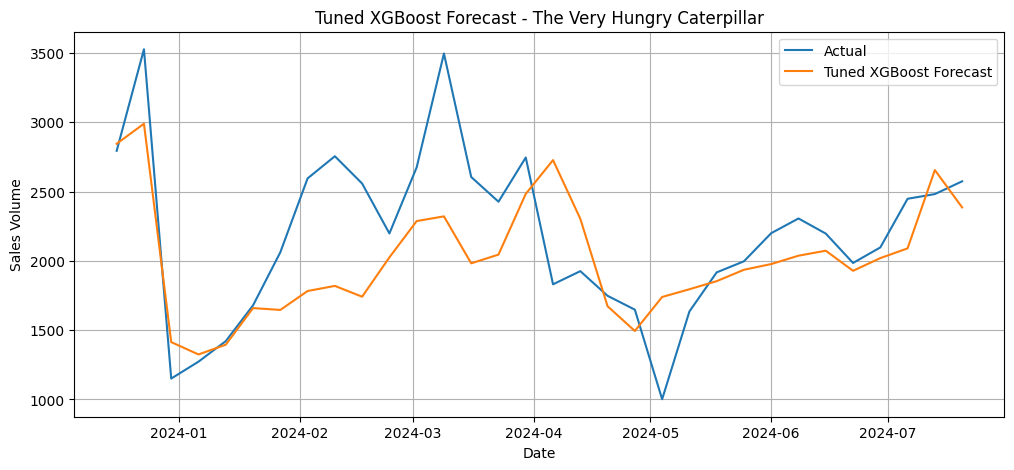

The Very Hungry Caterpillar
Model: Tuned XGBoost
MAE:  341.37
RMSE: 460.76
MAPE: 15.76%


In [ ]:
caterpillar_xgb_tuned_results = evaluate_forecast(
    caterpillar_test,
    caterpillar_xgb_tuned_pred,
    "The Very Hungry Caterpillar",
    "Tuned XGBoost"
)

Tuning substantially improved XGBoost, reducing MAE from 486.54 to 341.37 and MAPE from 23.37% to 15.76%. The selected 52-week window may help capture the annual sales pattern. Tuned XGBoost achieved lower MAE and MAPE than SARIMA, while SARIMA had a slightly lower RMSE, indicating fewer large forecast errors.

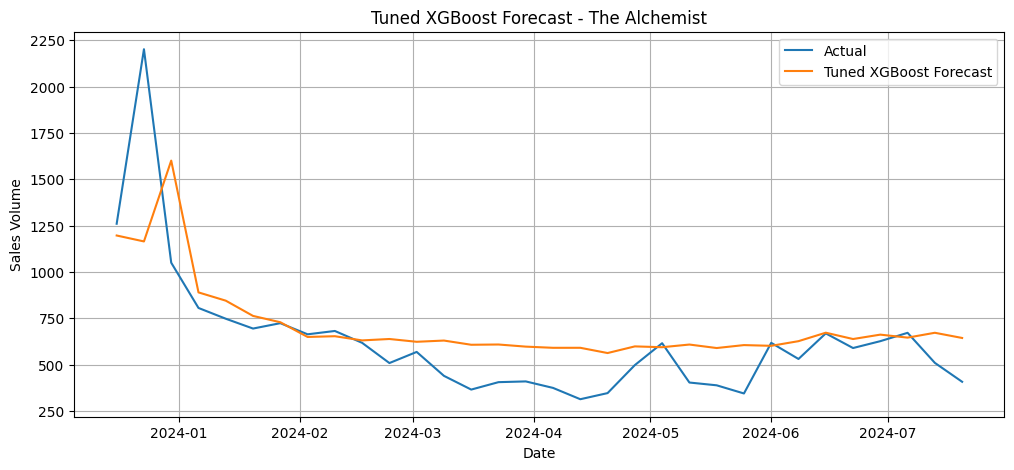

The Alchemist
Model: Tuned XGBoost
MAE:  159.05
RMSE: 251.33
MAPE: 28.92%


In [ ]:
alchemist_xgb_tuned_results = evaluate_forecast(
    alchemist_test,
    alchemist_xgb_tuned_pred,
    "The Alchemist",
    "Tuned XGBoost"
)

Tuning did not improve XGBoost for The Alchemist. The tuned model achieved an MAE of 159.05, RMSE of 251.33 and MAPE of 28.92%, performing worse than both baseline XGBoost and SARIMA. Although the 14-week window performed well during validation, it did not generalise as effectively to the final 32-week test period.

## LSTM

In [ ]:
X_cat_lstm, y_cat_lstm, scaler_cat = prepare_lstm_data(caterpillar_train,lookback)

X_alc_lstm, y_alc_lstm, scaler_alc = prepare_lstm_data(alchemist_train,lookback)

In [ ]:
print("Caterpillar:", X_cat_lstm.shape, y_cat_lstm.shape)
print("Alchemist:", X_alc_lstm.shape, y_alc_lstm.shape)

Caterpillar: (595, 28, 1) (595,)
Alchemist: (595, 28, 1) (595,)


In [ ]:
caterpillar_lstm = fit_lstm(X_cat_lstm,y_cat_lstm,lookback)
alchemist_lstm = fit_lstm(X_alc_lstm,y_alc_lstm,lookback)

In [ ]:
caterpillar_lstm_pred = recursive_forecast(
    history=caterpillar_train.values,
    horizon=len(caterpillar_test),
    predict_fn=lambda history: predict_next_lstm(
        caterpillar_lstm,
        history,
        scaler_cat,
        lookback
    )
)

In [ ]:
alchemist_lstm_pred = recursive_forecast(
    history=alchemist_train.values,
    horizon=len(alchemist_test),
    predict_fn=lambda history: predict_next_lstm(
        alchemist_lstm,
        history,
        scaler_alc,
        lookback
    )
)

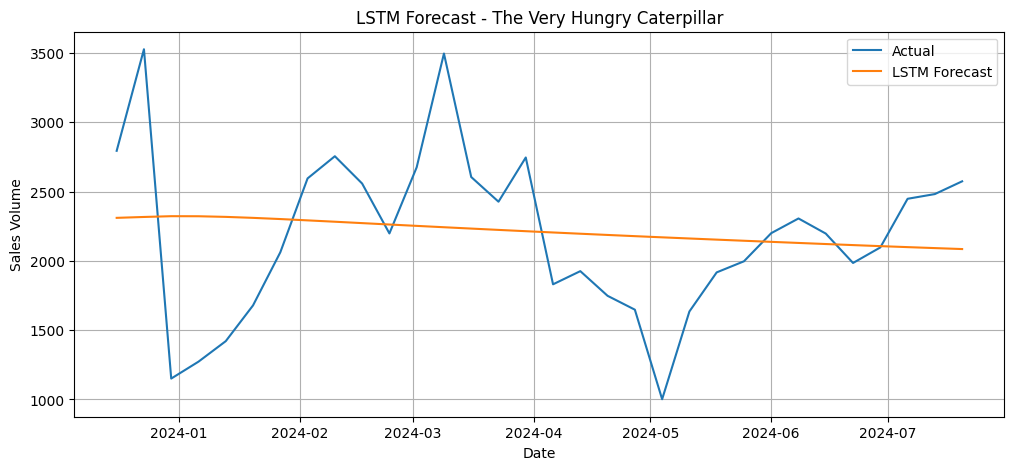

The Very Hungry Caterpillar
Model: LSTM
MAE:  467.58
RMSE: 586.80
MAPE: 25.46%


In [ ]:
caterpillar_lstm_results = evaluate_forecast(
    caterpillar_test,
    caterpillar_lstm_pred,
    "The Very Hungry Caterpillar",
    "LSTM"
)

The baseline LSTM produced a smooth forecast and struggled to capture sharp weekly fluctuations. It achieved an MAE of 467.58, RMSE of 586.80 and MAPE of 25.46%, performing worse than SARIMA and tuned XGBoost. The model used a simple architecture with a fixed 28-week lookback, so hyperparameter tuning was explored next.

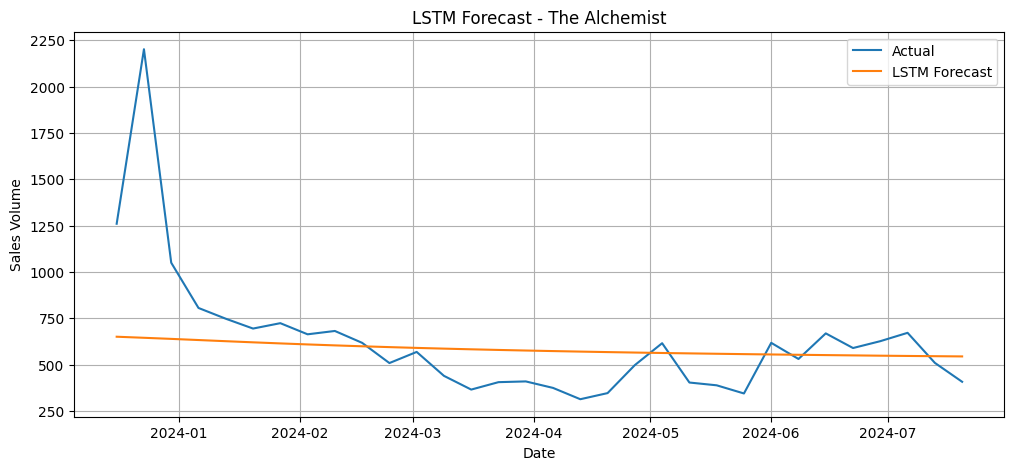

The Alchemist
Model: LSTM
MAE:  186.54
RMSE: 330.12
MAPE: 28.62%


In [ ]:
alchemist_lstm_results = evaluate_forecast(
    alchemist_test,
    alchemist_lstm_pred,
    "The Alchemist",
    "LSTM"
)

The baseline LSTM produced a smooth forecast and struggled to capture sharp weekly fluctuations. It achieved an MAE of 186.54, RMSE of 330.12 and MAPE of 28.62%, performing worse than SARIMA and baseline XGBoost. The model used a simple architecture with a fixed 28-week lookback, so hyperparameter tuning was explored next.

## Tuned LSTM

In [ ]:
cat_tuner, cat_best_hp, caterpillar_lstm_tuned = tune_lstm(X_cat_lstm,y_cat_lstm,"caterpillar_lstm")

Trial 10 Complete [00h 00m 43s]
val_loss: 0.012108396738767624

Best val_loss So Far: 0.012108396738767624
Total elapsed time: 00h 07m 46s


In [ ]:
print("Best hyperparameters:")
for key, value in cat_best_hp.values.items():
    print(f"{key}: {value}")

Best hyperparameters:
input_units: 32
n_layers: 2
lstm_0_units: 32
final_lstm_units: 88
dropout_rate: 0.0
lstm_1_units: 32
lstm_2_units: 56


KerasTuner selected an architecture with 32 initial LSTM units, two additional LSTM layers with 32 units each, a final LSTM layer with 88 units, and no dropout. The reported lstm_2_units value is inactive because the selected number of intermediate layers was two.

In [ ]:
caterpillar_lstm_tuned = tuned_model(cat_best_hp)
caterpillar_lstm_tuned.fit(X_cat_lstm,y_cat_lstm,epochs=30,batch_size=32,verbose=0)

In [ ]:
caterpillar_lstm_tuned_pred = recursive_forecast(
    history=caterpillar_train.values,
    horizon=len(caterpillar_test),
    predict_fn=lambda history: predict_next_lstm(
        caterpillar_lstm_tuned,
        history,
        scaler_cat,
        lookback
    )
)

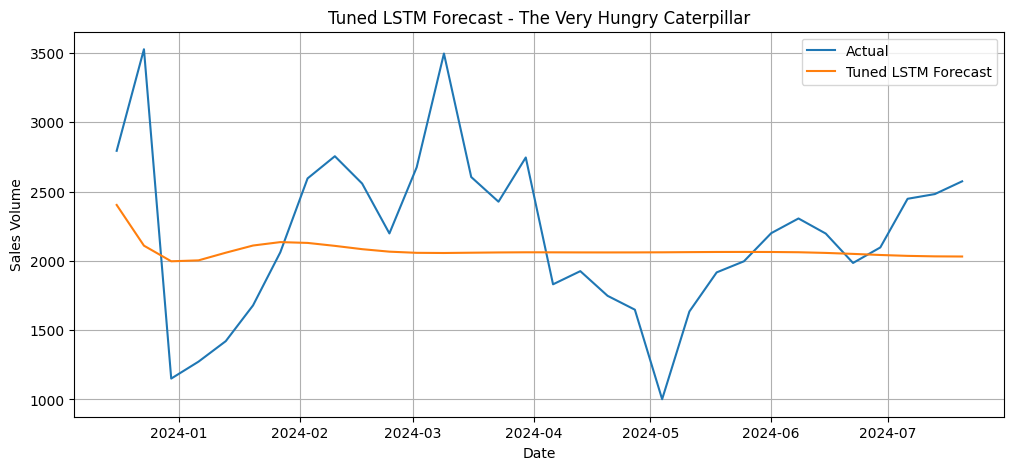

The Very Hungry Caterpillar
Model: Tuned LSTM
MAE:  460.45
RMSE: 577.73
MAPE: 23.15%


In [ ]:
caterpillar_lstm_tuned_results = evaluate_forecast(
    caterpillar_test,
    caterpillar_lstm_tuned_pred,
    "The Very Hungry Caterpillar",
    "Tuned LSTM"
)

The tuned LSTM improved slightly over the baseline model, achieving an MAE of 460.45, RMSE of 577.73 and MAPE of 23.15%. However, it still struggled to capture sharp weekly fluctuations and remained less accurate than SARIMA and tuned XGBoost.

In [ ]:
alc_tuner, alc_best_hp, alchemist_lstm_tuned = tune_lstm(X_alc_lstm,y_alc_lstm,"alchemist_lstm")

Trial 10 Complete [00h 00m 51s]
val_loss: 0.015502681024372578

Best val_loss So Far: 0.006861040368676186
Total elapsed time: 00h 10m 06s


In [ ]:
print("Best hyperparameters for The Alchemist:")
for key, value in alc_best_hp.values.items():
    print(f"{key}: {value}")

Best hyperparameters for The Alchemist:
input_units: 128
n_layers: 1
lstm_0_units: 56
final_lstm_units: 120
dropout_rate: 0.2
lstm_1_units: 40
lstm_2_units: 48


KerasTuner selected an architecture with 128 initial LSTM units, one additional LSTM layer with 56 units, a final LSTM layer with 120 units, and a dropout rate of 0.2. The reported lstm_1_units and lstm_2_units are inactive because only one intermediate layer was selected.

In [ ]:
alchemist_lstm_tuned = tuned_model(alc_best_hp)
alchemist_lstm_tuned.fit(X_alc_lstm,y_alc_lstm,epochs=30,batch_size=32,verbose=0)

In [ ]:
alchemist_lstm_tuned_pred = recursive_forecast(
    history=alchemist_train.values,
    horizon=len(alchemist_test),
    predict_fn=lambda history: predict_next_lstm(
        alchemist_lstm_tuned,
        history,
        scaler_alc,
        lookback
    )
)

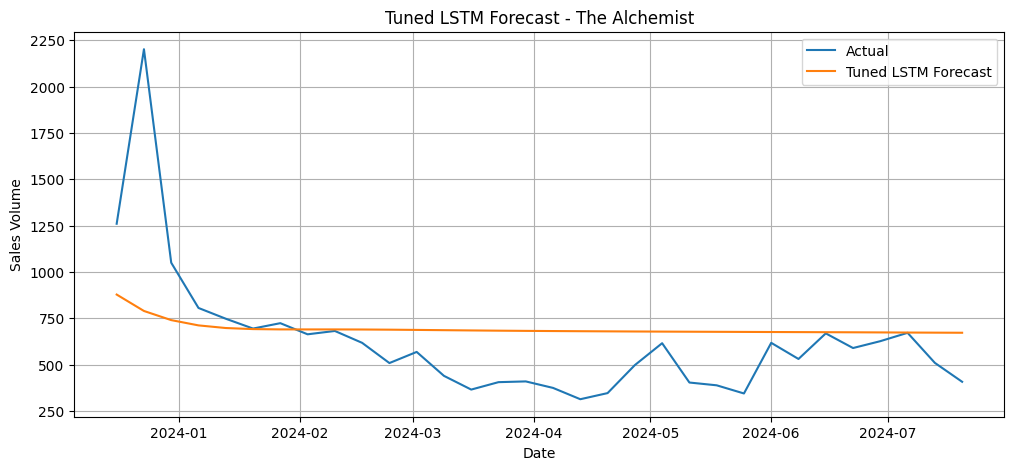

The Alchemist
Model: Tuned LSTM
MAE:  209.93
RMSE: 325.29
MAPE: 38.56%


In [ ]:
alchemist_lstm_tuned_results = evaluate_forecast(
    alchemist_test,
    alchemist_lstm_tuned_pred,
    "The Alchemist",
    "Tuned LSTM"
)

The tuned LSTM did not consistently improve performance for The Alchemist. It achieved an MAE of 209.93, RMSE of 325.29 and MAPE of 38.56%. Although RMSE improved slightly, MAE and MAPE worsened, indicating that the tuned architecture did not generalise well to the final 32-week test period.

# Hybrid model

In [ ]:
def get_residual_series(model, train_series):
    """
    Extract SARIMA training residuals and align them
    with the original training dates.
    """
    residuals = pd.Series(model.resid(),index=train_series.index)
    return residuals.dropna()

In [ ]:
def prepare_residual_lstm_data(residual_series, lookback):

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(residual_series.values.reshape(-1, 1))
    X, y = [], []

    for i in range(lookback, len(scaled)):
        X.append(scaled[i-lookback:i, 0])
        y.append(scaled[i, 0])

    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y, scaler

In [ ]:
def test_parallel_weights(test,sarima_pred,lstm_pred,title,weights=np.arange(0, 1.1, 0.1)):
    results = []

    sarima_pred = np.asarray(sarima_pred)
    lstm_pred = np.asarray(lstm_pred)

    for w_sarima in weights:
        w_lstm = 1 - w_sarima
        hybrid_pred = (w_sarima * sarima_pred+ w_lstm * lstm_pred)
        mae = mean_absolute_error(test, hybrid_pred)
        rmse = np.sqrt(mean_squared_error(test, hybrid_pred))

        non_zero = test != 0
        mape = mean_absolute_percentage_error(test[non_zero],hybrid_pred[non_zero]) * 100

        results.append({
            "SARIMA_weight": w_sarima,
            "LSTM_weight": w_lstm,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })

    results_df = pd.DataFrame(results)

    return results_df

In [ ]:
caterpillar_sarima_resid = get_residual_series(caterpillar_arima,caterpillar_train)

alchemist_sarima_resid = get_residual_series(alchemist_arima,alchemist_train)

In [ ]:
print("Caterpillar residuals:",caterpillar_sarima_resid.shape)
print("Alchemist residuals:",alchemist_sarima_resid.shape)

display(caterpillar_sarima_resid.head())
display(alchemist_sarima_resid.head())

Caterpillar residuals: (623,)
Alchemist residuals: (623,)


,0
End_Date,
2012-01-07,509.692445
2012-01-14,9.739162
2012-01-21,61.806025
2012-01-28,56.733062
2012-02-04,534.419850


,0
End_Date,
2012-01-07,518.000000
2012-01-14,17.640305
2012-01-21,-52.088716
2012-01-28,28.067930
2012-02-04,75.890408


In [ ]:
X_cat_resid, y_cat_resid, scaler_cat_resid = prepare_residual_lstm_data(caterpillar_sarima_resid,lookback)
X_alc_resid, y_alc_resid, scaler_alc_resid = prepare_residual_lstm_data(alchemist_sarima_resid,lookback)

In [ ]:
print("Caterpillar residual LSTM:", X_cat_resid.shape, y_cat_resid.shape)
print("Alchemist residual LSTM:", X_alc_resid.shape, y_alc_resid.shape)

Caterpillar residual LSTM: (595, 28, 1) (595,)
Alchemist residual LSTM: (595, 28, 1) (595,)


In [ ]:
cat_resid_tuner, cat_resid_best_hp, cat_resid_lstm = tune_lstm(X_cat_resid,y_cat_resid,"caterpillar_residual_lstm")
print("Best residual-LSTM hyperparameters - Caterpillar:")
for key, value in cat_resid_best_hp.values.items():
    print(f"{key}: {value}")

Trial 10 Complete [00h 00m 42s]
val_loss: 0.005774246528744698

Best val_loss So Far: 0.005763606633991003
Total elapsed time: 00h 09m 22s
Best residual-LSTM hyperparameters - Caterpillar:
input_units: 120
n_layers: 1
lstm_0_units: 24
final_lstm_units: 64
dropout_rate: 0.1


KerasTuner selected a residual-LSTM with 120 initial units, one intermediate layer with 24 units, a final LSTM layer with 64 units, and dropout of 0.1. The best validation loss was approximately 0.00576.

In [ ]:
alc_resid_tuner, alc_resid_best_hp, alc_resid_lstm = tune_lstm(X_alc_resid,y_alc_resid,"alchemist_residual_lstm")
print("Best residual-LSTM hyperparameters - Alchemist:")
for key, value in alc_resid_best_hp.values.items():
    print(f"{key}: {value}")

Trial 10 Complete [00h 01m 03s]
val_loss: 0.009549504145979881

Best val_loss So Far: 0.009549504145979881
Total elapsed time: 00h 09m 39s
Best residual-LSTM hyperparameters - Alchemist:
input_units: 8
n_layers: 3
lstm_0_units: 104
final_lstm_units: 80
dropout_rate: 0.4
lstm_1_units: 104
lstm_2_units: 8


KerasTuner selected a residual-LSTM with 8 initial units, three intermediate layers with 104, 104 and 8 units, a final LSTM layer with 80 units, and dropout of 0.4. The best validation loss was approximately 0.00955.

In [ ]:
cat_resid_lstm_final = tuned_model(cat_resid_best_hp)

cat_resid_lstm_final.fit(X_cat_resid,y_cat_resid,epochs=30,batch_size=32,verbose=0)

In [ ]:
alc_resid_lstm_final = tuned_model(alc_resid_best_hp)

alc_resid_lstm_final.fit(X_alc_resid,y_alc_resid,epochs=30,batch_size=32,verbose=0)

In [ ]:
cat_resid_pred = recursive_forecast(
    history=caterpillar_sarima_resid.values,
    horizon=len(caterpillar_test),
    predict_fn=lambda history: predict_next_lstm(
        cat_resid_lstm_final,
        history,
        scaler_cat_resid,
        lookback
    )
)

In [ ]:
alc_resid_pred = recursive_forecast(
    history=alchemist_sarima_resid.values,
    horizon=len(alchemist_test),
    predict_fn=lambda history: predict_next_lstm(
        alc_resid_lstm_final,
        history,
        scaler_alc_resid,
        lookback
    )
)

In [ ]:
print("Caterpillar residual predictions:", len(cat_resid_pred))
print("Alchemist residual predictions:", len(alc_resid_pred))

Caterpillar residual predictions: 32
Alchemist residual predictions: 32


In [ ]:
cat_sarima_pred = caterpillar_arima.predict(n_periods=len(caterpillar_test))

alc_sarima_pred = alchemist_arima.predict(n_periods=len(alchemist_test))

In [ ]:
cat_sequential_pred = (cat_sarima_pred + np.asarray(cat_resid_pred))

alc_sequential_pred = (alc_sarima_pred +np.asarray(alc_resid_pred))

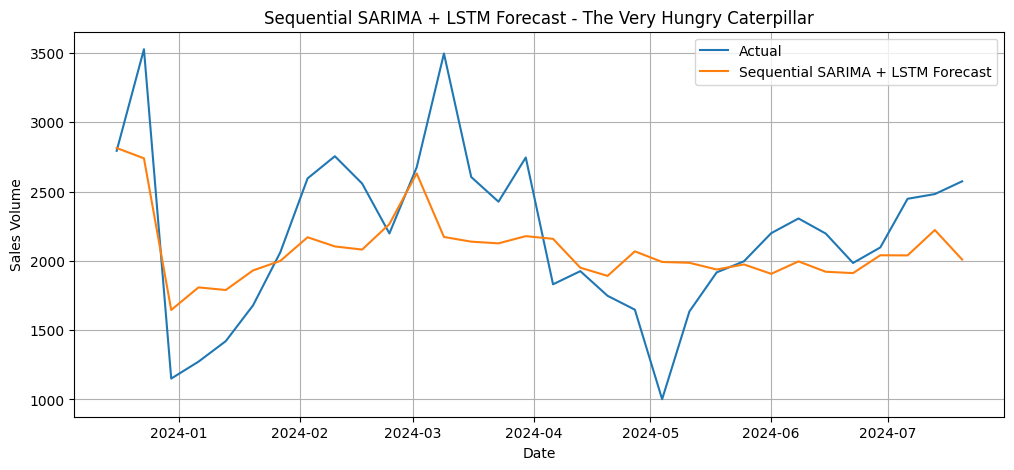

The Very Hungry Caterpillar
Model: Sequential SARIMA + LSTM
MAE:  355.79
RMSE: 461.10
MAPE: 17.95%


In [ ]:
cat_sequential_results = evaluate_forecast(
    caterpillar_test,
    cat_sequential_pred,
    "The Very Hungry Caterpillar",
    "Sequential SARIMA + LSTM"
)

The sequential SARIMA–LSTM model achieved an MAE of 355.79, RMSE of 461.10 and MAPE of 17.95%. Compared with SARIMA alone, the hybrid slightly improved MAPE but had higher MAE and RMSE, suggesting only limited benefit from the residual LSTM.

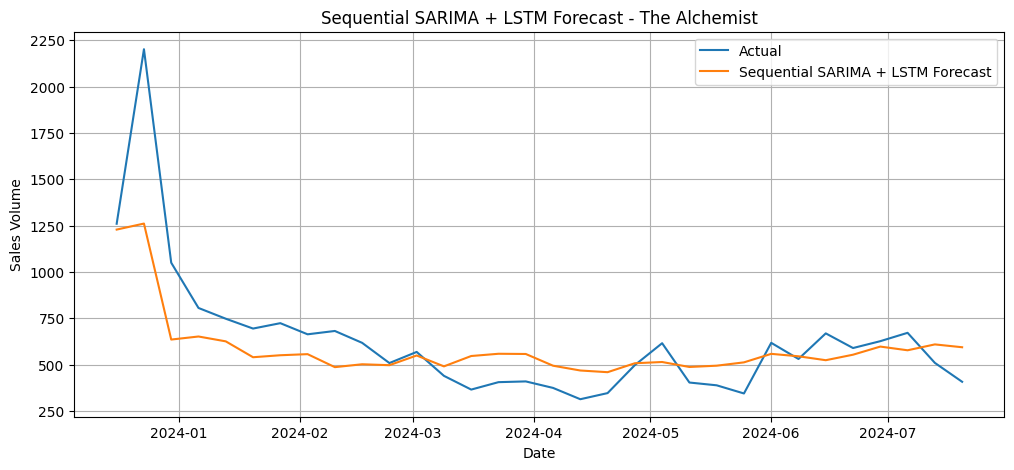

The Alchemist
Model: Sequential SARIMA + LSTM
MAE:  140.31
RMSE: 215.10
MAPE: 22.58%


In [ ]:
alc_sequential_results = evaluate_forecast(
    alchemist_test,
    alc_sequential_pred,
    "The Alchemist",
    "Sequential SARIMA + LSTM"
)

The sequential SARIMA–LSTM model achieved an MAE of 140.31, RMSE of 215.10 and MAPE of 22.58%. Compared with SARIMA alone, the hybrid slightly improved MAPE but had higher MAE and RMSE, suggesting only limited additional predictive value from the residual LSTM.

In [ ]:
cat_parallel_results = test_parallel_weights(
    test=caterpillar_test,
    sarima_pred=cat_sarima_pred,
    lstm_pred=caterpillar_lstm_tuned_pred,
    title="The Very Hungry Caterpillar"
)

display(cat_parallel_results.sort_values("MAE"))

,SARIMA_weight,LSTM_weight,MAE,RMSE,MAPE
10,1.0,0.0,349.063389,448.928787,18.467512
9,0.9,0.1,354.368787,458.196576,18.711850
8,0.8,0.2,362.328029,468.424447,19.055117
7,0.7,0.3,373.140348,479.550970,19.500500
6,0.6,0.4,383.952669,491.515133,19.945882
5,0.5,0.5,395.237525,504.257303,20.413797
4,0.4,0.6,407.824562,517.720036,20.941206
3,0.3,0.7,420.980089,531.848641,21.494478
2,0.2,0.8,434.135609,546.591461,22.047751
1,0.1,0.9,447.291136,561.900164,22.601022


The parallel weight test showed that pure SARIMA achieved the lowest MAE, RMSE and MAPE. Forecast accuracy decreased as the LSTM weight increased, indicating that combining the tuned LSTM with SARIMA did not improve performance.

In [ ]:
alc_parallel_results = test_parallel_weights(
    test=alchemist_test,
    sarima_pred=alc_sarima_pred,
    lstm_pred=alchemist_lstm_tuned_pred,
    title="The Alchemist"
)

display(alc_parallel_results.sort_values("MAE"))

,SARIMA_weight,LSTM_weight,MAE,RMSE,MAPE
10,1.0,0.0,139.015550,213.377201,22.920477
9,0.9,0.1,143.356812,221.131267,24.032440
8,0.8,0.2,148.203071,229.911351,25.233499
7,0.7,0.3,153.623809,239.604686,26.531100
6,0.6,0.4,159.566716,250.105111,27.913936
5,0.5,0.5,165.821886,261.315349,29.347300
4,0.4,0.6,172.607936,273.148022,30.866615
3,0.3,0.7,181.274012,285.525754,32.690594
2,0.2,0.8,190.057515,298.380721,34.532260
1,0.1,0.9,199.487070,311.653874,36.471220


For The Alchemist, pure SARIMA achieved the lowest MAE, RMSE and MAPE. Forecast accuracy consistently decreased as the LSTM weight increased, showing that the parallel combination did not improve upon standalone SARIMA.

# Monthly prediction

In [ ]:
def create_monthly_series(ts):
    return ts.resample("ME").sum()

In [ ]:
def monthly_train_test_split(ts, test_size=8):
    train = ts.iloc[:-test_size]
    test = ts.iloc[-test_size:]
    return train, test

In [ ]:
def fit_monthly_auto_arima(train, title):

    model = auto_arima(
        y=train,
        start_p=0,
        start_q=0,
        max_p=2,
        max_q=2,
        d=None,
        max_d=1,

        start_P=0,
        start_Q=0,
        max_P=1,
        max_Q=1,
        D=None,
        max_D=1,

        m=12,
        seasonal=True,

        information_criterion="aic",
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=True,
        maxiter=25
    )

    print(f"\nBest monthly model for {title}:")
    print(model.summary())

    return model

In [ ]:
caterpillar_monthly = create_monthly_series(caterpillar_ts)

alchemist_monthly = create_monthly_series(alchemist_ts)

In [ ]:
print("Caterpillar monthly observations:", len(caterpillar_monthly))
print("Alchemist monthly observations:", len(alchemist_monthly))

print("\nCaterpillar date range:")
print(caterpillar_monthly.index.min(), "to", caterpillar_monthly.index.max())

print("\nAlchemist date range:")
print(alchemist_monthly.index.min(), "to", alchemist_monthly.index.max())

Caterpillar monthly observations: 151
Alchemist monthly observations: 151

Caterpillar date range:
2012-01-31 00:00:00 to 2024-07-31 00:00:00

Alchemist date range:
2012-01-31 00:00:00 to 2024-07-31 00:00:00


In [ ]:
cat_month_train, cat_month_test = monthly_train_test_split(caterpillar_monthly)

alc_month_train, alc_month_test = monthly_train_test_split(alchemist_monthly)

In [ ]:
print("Caterpillar")
print("Train:", len(cat_month_train))
print("Test:", len(cat_month_test))
print("Train ends:", cat_month_train.index[-1])
print("Test starts:", cat_month_test.index[0])

print("\nAlchemist")
print("Train:", len(alc_month_train))
print("Test:", len(alc_month_test))
print("Train ends:", alc_month_train.index[-1])
print("Test starts:", alc_month_test.index[0])

Caterpillar
Train: 143
Test: 8
Train ends: 2023-11-30 00:00:00
Test starts: 2023-12-31 00:00:00

Alchemist
Train: 143
Test: 8
Train ends: 2023-11-30 00:00:00
Test starts: 2023-12-31 00:00:00


Weekly sales were aggregated into monthly totals using summation. The resulting monthly series contained 151 observations for each book. The final 8 months were reserved as the test period, leaving 143 monthly observations for model training.

In [ ]:
monthly_window = 12
cat_month_lagged = create_lag_features(cat_month_train,monthly_window)
alc_month_lagged = create_lag_features(alc_month_train,monthly_window)

In [ ]:
X_cat_month = cat_month_lagged.drop(columns="y")
y_cat_month = cat_month_lagged["y"]

X_alc_month = alc_month_lagged.drop(columns="y")
y_alc_month = alc_month_lagged["y"]

In [ ]:
print("Caterpillar:", X_cat_month.shape, y_cat_month.shape)
print("Alchemist:", X_alc_month.shape, y_alc_month.shape)

Caterpillar: (131, 12) (131,)
Alchemist: (131, 12) (131,)


## XGboost

In [ ]:
cat_month_xgb = fit_xgboost(X_cat_month,y_cat_month)

alc_month_xgb = fit_xgboost(X_alc_month,y_alc_month)

In [ ]:
cat_month_xgb_pred = recursive_forecast(
    history=cat_month_train.values,
    horizon=len(cat_month_test),
    predict_fn=lambda history: predict_next_xgb(
        cat_month_xgb,
        history,
        monthly_window
    )
)

In [ ]:
alc_month_xgb_pred = recursive_forecast(
    history=alc_month_train.values,
    horizon=len(alc_month_test),
    predict_fn=lambda history: predict_next_xgb(
        alc_month_xgb,
        history,
        monthly_window
    )
)

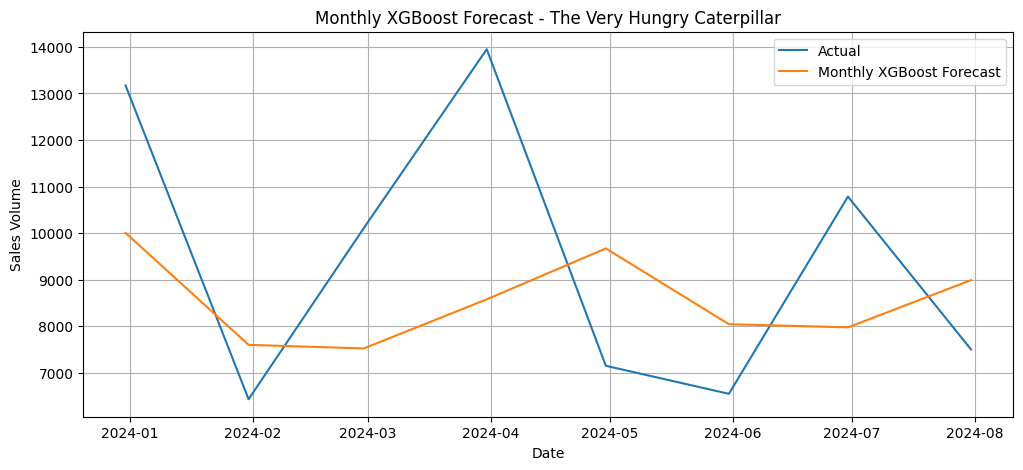

The Very Hungry Caterpillar
Model: Monthly XGBoost
MAE:  2574.04
RMSE: 2862.57
MAPE: 26.26%


In [ ]:
cat_month_xgb_results = evaluate_forecast(
    cat_month_test,
    cat_month_xgb_pred,
    "The Very Hungry Caterpillar",
    "Monthly XGBoost"
)

The monthly XGBoost model achieved an MAE of 2,574.04, RMSE of 2,862.57 and MAPE of 26.26%. It captures the general sales level but produces a smoother forecast and underestimates some large monthly sales peaks.

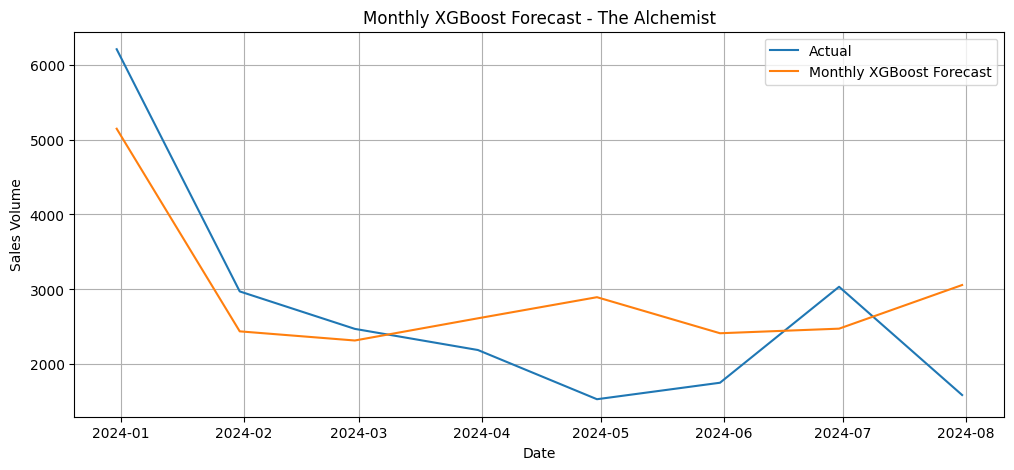

The Alchemist
Model: Monthly XGBoost
MAE:  777.81
RMSE: 892.57
MAPE: 37.23%


In [ ]:
alc_month_xgb_results = evaluate_forecast(
    alc_month_test,
    alc_month_xgb_pred,
    "The Alchemist",
    "Monthly XGBoost"
)

The monthly XGBoost model achieved an MAE of 777.81, RMSE of 892.57 and MAPE of 37.23%. It captures the general sales level but misses several month-to-month fluctuations, resulting in relatively high percentage error.

## AUTO ARIMA

In [ ]:
cat_month_sarima = fit_monthly_auto_arima(cat_month_train,"The Very Hungry Caterpillar")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2649.409, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2597.383, Time=0.58 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2592.077, Time=0.93 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2647.468, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=2597.774, Time=0.24 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=2574.765, Time=0.48 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2587.743, Time=0.33 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=2602.473, Time=0.34 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=2571.857, Time=0.57 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=2586.215, Time=0.43 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=2581.339, Time=0.35 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=2596.982, Time=0.20 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2583.996, Time=0.42 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=2580.392, Time=0.55 sec
 ARIMA(1,1,2)(1,0,1

Auto ARIMA selected ARIMA(1,1,1)(1,0,1)[12] with an AIC of 2569.60, capturing both non-seasonal and annual seasonal structure. The Ljung–Box test showed little residual autocorrelation, although some non-normality and changing variance remained.

In [ ]:
alc_month_sarima = fit_monthly_auto_arima(alc_month_train,"The Alchemist")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2352.814, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2321.034, Time=0.62 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2312.014, Time=1.54 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2638.083, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=2342.425, Time=0.10 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=2312.260, Time=0.98 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=2335.894, Time=0.47 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=2327.361, Time=0.18 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=2308.339, Time=0.29 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=2339.055, Time=0.05 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=2301.933, Time=0.40 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=2303.362, Time=0.39 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=2307.647, Time=0.32 sec
 ARIMA(2,0,1)(1,0,1)[12] intercept   : AIC=2298.712, Time=0.49 sec
 ARIMA(2,0,1)(0,0,1

Auto ARIMA selected ARIMA(1,0,2)(1,0,1)[12] with an AIC of 2287.83, capturing both non-seasonal and annual seasonal structure. The Ljung–Box test showed little residual autocorrelation, although some non-normality and changing variance remained.

In [ ]:
cat_month_sarima_pred = cat_month_sarima.predict(n_periods=len(cat_month_test))

alc_month_sarima_pred = alc_month_sarima.predict(n_periods=len(alc_month_test))

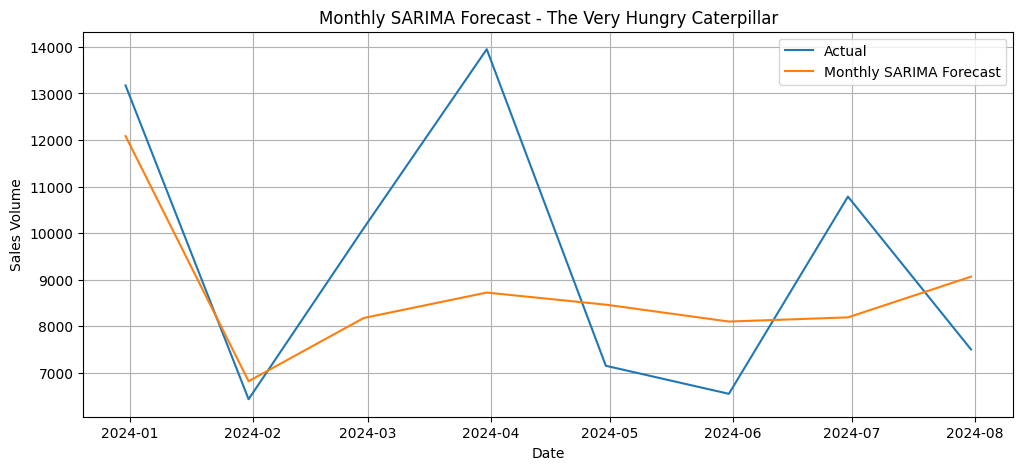

The Very Hungry Caterpillar
Model: Monthly SARIMA
MAE:  1955.51
RMSE: 2388.25
MAPE: 19.71%


In [ ]:
cat_month_sarima_results = evaluate_forecast(
    cat_month_test,
    cat_month_sarima_pred,
    "The Very Hungry Caterpillar",
    "Monthly SARIMA"
)

The monthly SARIMA model achieved an MAE of 1,955.51, RMSE of 2,388.25 and MAPE of 19.71% over the eight-month test period. These results are better than the monthly XGBoost model across all three metrics. The SARIMA forecast follows the broad monthly sales pattern more closely, although some of the larger peaks remain underestimated. This suggests that explicitly modelling annual seasonal structure is particularly useful for the monthly sales series.

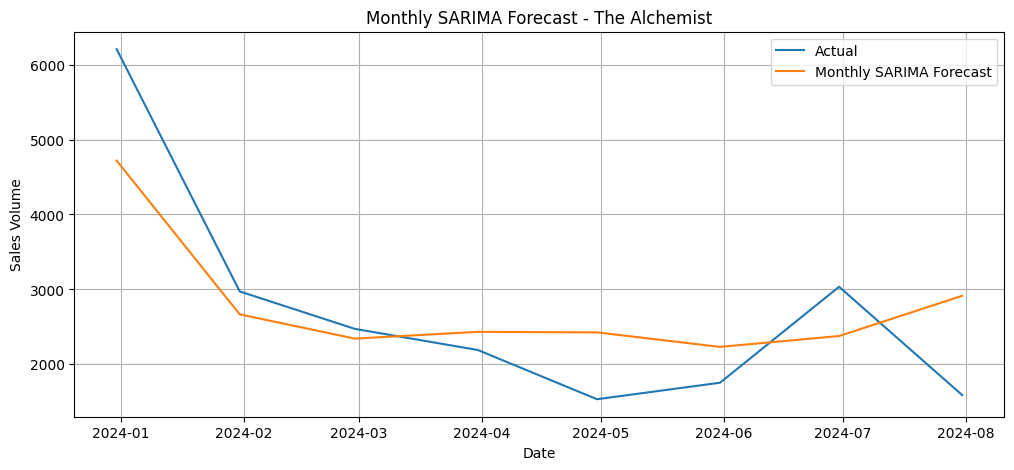

The Alchemist
Model: Monthly SARIMA
MAE:  689.79
RMSE: 836.12
MAPE: 30.12%


In [ ]:
alc_month_sarima_results = evaluate_forecast(
    alc_month_test,
    alc_month_sarima_pred,
    "The Alchemist",
    "Monthly SARIMA"
)

The monthly SARIMA model achieved an MAE of 689.79, RMSE of 836.12 and MAPE of 30.12% over the final eight months. This represents an improvement over the monthly XGBoost model across all three evaluation metrics. The model captures the broad monthly sales pattern reasonably well, although it underestimates the large initial sales peak and overestimates several lower-sales months. Overall, SARIMA provides the stronger monthly forecasting approach for The Alchemist.

# Comparecomparison

In [ ]:
def get_metrics(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))

    non_zero = actual != 0
    mape = mean_absolute_percentage_error(
        actual[non_zero],
        pred[non_zero]
    ) * 100

    return mae, rmse, mape

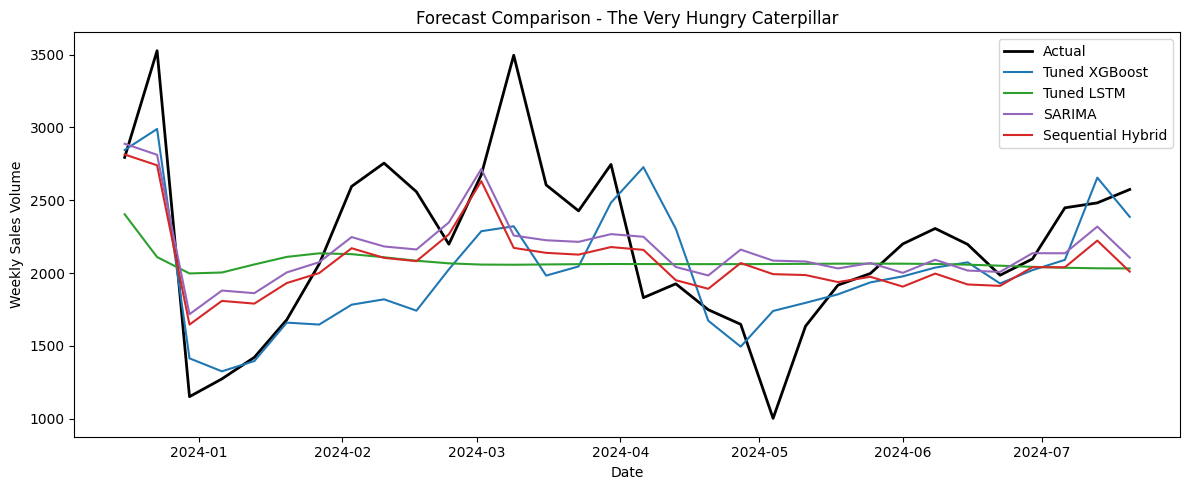

In [ ]:
# Compare weekly forecasts - The Very Hungry Caterpillar
plt.figure(figsize=(12, 5))

plt.plot(caterpillar_test.index,caterpillar_test.values,label="Actual",color="black",linewidth=2)
plt.plot(caterpillar_test.index,caterpillar_xgb_tuned_pred,label="Tuned XGBoost",color="#1f77b4")
plt.plot(caterpillar_test.index,caterpillar_lstm_tuned_pred,label="Tuned LSTM",color="#2ca02c")
plt.plot(caterpillar_test.index,cat_sarima_pred,label="SARIMA",color="#9467bd")
plt.plot(caterpillar_test.index,cat_sequential_pred,label="Sequential Hybrid",color="#d62728")

plt.title("Forecast Comparison - The Very Hungry Caterpillar")
plt.xlabel("Date")
plt.ylabel("Weekly Sales Volume")
plt.legend()
plt.tight_layout()
plt.show()

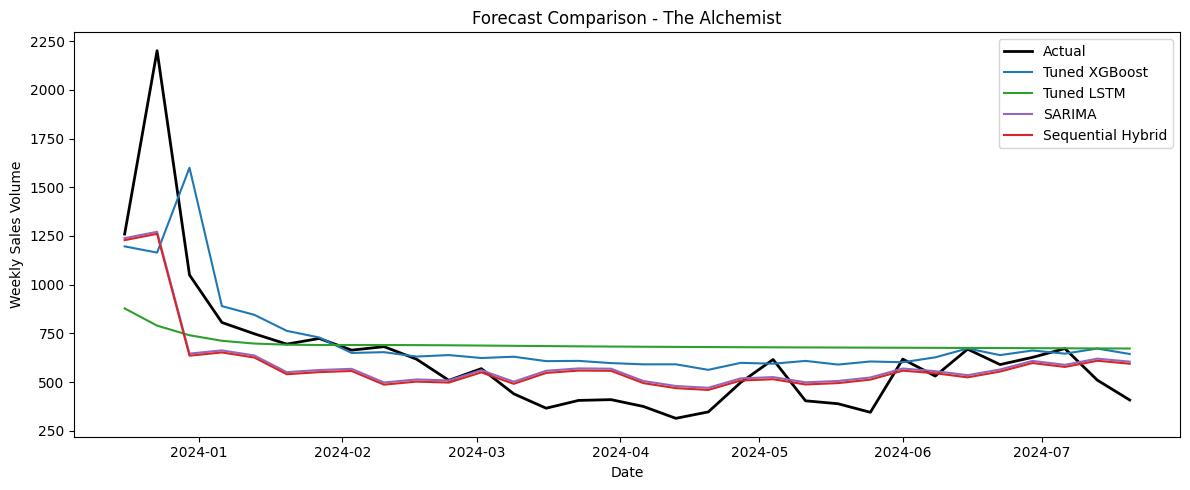

In [ ]:
# Compare weekly forecasts - The Alchemist
plt.figure(figsize=(12, 5))

plt.plot(alchemist_test.index,alchemist_test.values,label="Actual",color="black",linewidth=2)
plt.plot(alchemist_test.index,alchemist_xgb_tuned_pred,label="Tuned XGBoost",color="#1f77b4")
plt.plot(alchemist_test.index,alchemist_lstm_tuned_pred,label="Tuned LSTM",color="#2ca02c")
plt.plot(alchemist_test.index,alc_sarima_pred,label="SARIMA",color="#9467bd")
plt.plot(alchemist_test.index,alc_sequential_pred,label="Sequential Hybrid",color="#d62728")

plt.title("Forecast Comparison - The Alchemist")
plt.xlabel("Date")
plt.ylabel("Weekly Sales Volume")
plt.legend()
plt.tight_layout()
plt.show()

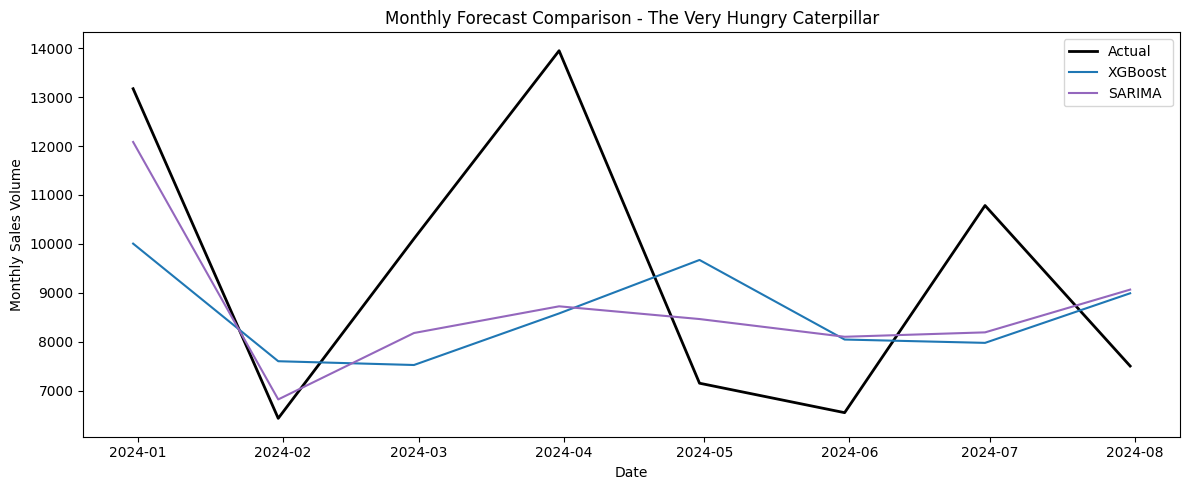

In [ ]:
# Monthly forecast comparison - The Very Hungry Caterpillar
plt.figure(figsize=(12, 5))

plt.plot(cat_month_test.index,cat_month_test.values,label="Actual",color="black",linewidth=2)
plt.plot(cat_month_test.index,cat_month_xgb_pred,label="XGBoost",color="#1f77b4")
plt.plot(cat_month_test.index,cat_month_sarima_pred,label="SARIMA",color="#9467bd")

plt.title("Monthly Forecast Comparison - The Very Hungry Caterpillar")
plt.xlabel("Date")
plt.ylabel("Monthly Sales Volume")
plt.legend()
plt.tight_layout()
plt.show()

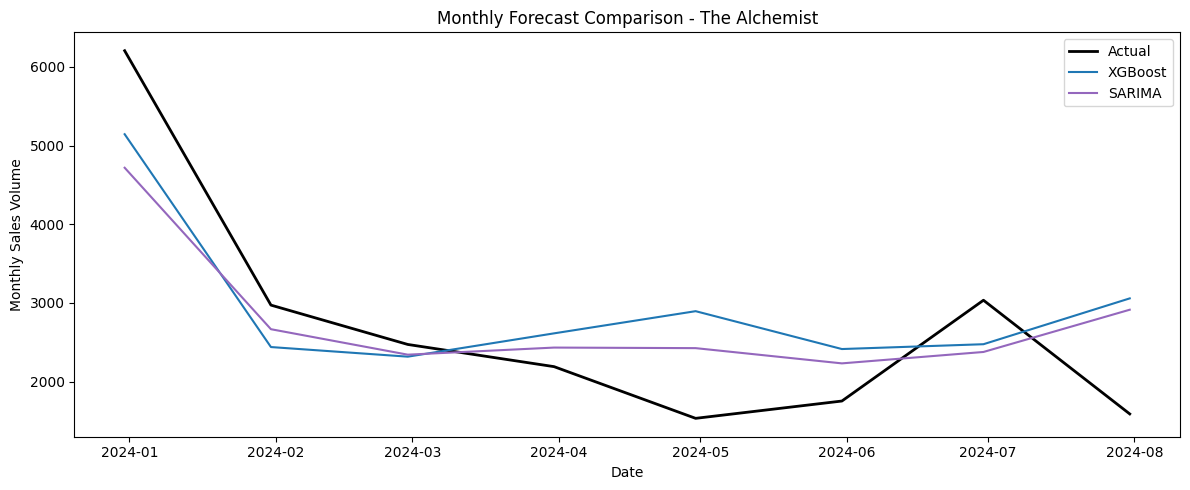

In [ ]:
# Monthly forecast comparison - The Alchemist
plt.figure(figsize=(12, 5))

plt.plot(alc_month_test.index,alc_month_test.values,label="Actual",color="black",linewidth=2)
plt.plot(alc_month_test.index,alc_month_xgb_pred,label="XGBoost",color="#1f77b4")
plt.plot(alc_month_test.index,alc_month_sarima_pred,label="SARIMA",color="#9467bd")

plt.title("Monthly Forecast Comparison - The Alchemist")
plt.xlabel("Date")
plt.ylabel("Monthly Sales Volume")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate latest weekly metrics automatically
cat_sarima_m = get_metrics(caterpillar_test, cat_sarima_pred)
cat_xgb_m = get_metrics(caterpillar_test, caterpillar_xgb_tuned_pred)
cat_lstm_m = get_metrics(caterpillar_test, caterpillar_lstm_tuned_pred)
cat_seq_m = get_metrics(caterpillar_test, cat_sequential_pred)

alc_sarima_m = get_metrics(alchemist_test, alc_sarima_pred)
alc_xgb_m = get_metrics(alchemist_test, alchemist_xgb_tuned_pred)
alc_lstm_m = get_metrics(alchemist_test, alchemist_lstm_tuned_pred)
alc_seq_m = get_metrics(alchemist_test, alc_sequential_pred)

In [ ]:
weekly_results_report = pd.DataFrame(
    {
        ("The Very Hungry Caterpillar", "MAE"):
            [cat_sarima_m[0], cat_xgb_m[0], cat_lstm_m[0], cat_seq_m[0]],

        ("The Very Hungry Caterpillar", "RMSE"):
            [cat_sarima_m[1], cat_xgb_m[1], cat_lstm_m[1], cat_seq_m[1]],

        ("The Very Hungry Caterpillar", "MAPE"):
            [cat_sarima_m[2], cat_xgb_m[2], cat_lstm_m[2], cat_seq_m[2]],

        ("The Alchemist", "MAE"):
            [alc_sarima_m[0], alc_xgb_m[0], alc_lstm_m[0], alc_seq_m[0]],

        ("The Alchemist", "RMSE"):
            [alc_sarima_m[1], alc_xgb_m[1], alc_lstm_m[1], alc_seq_m[1]],

        ("The Alchemist", "MAPE"):
            [alc_sarima_m[2], alc_xgb_m[2], alc_lstm_m[2], alc_seq_m[2]]
    },
    index=[
        "SARIMA",
        "Tuned XGBoost",
        "Tuned LSTM",
        "Sequential SARIMA-LSTM"
    ]
)

weekly_results_report.index.name = "Model"

display(weekly_results_report.round(2))

The Very Hungry Caterpillar                 \
                                               MAE    RMSE   MAPE   
Model                                                               
SARIMA                                      349.06  448.93  18.47   
Tuned XGBoost                               341.37  460.76  15.76   
Tuned LSTM                                  460.45  577.73  23.15   
Sequential SARIMA-LSTM                      355.79  461.10  17.95   

                       The Alchemist                 
                                 MAE    RMSE   MAPE  
Model                                                
SARIMA                        139.02  213.38  22.92  
Tuned XGBoost                 159.05  251.33  28.92  
Tuned LSTM                    209.93  325.29  38.56  
Sequential SARIMA-LSTM        140.31  215.10  22.58

In [ ]:
cat_month_xgb_m = get_metrics(cat_month_test, cat_month_xgb_pred)
cat_month_sarima_m = get_metrics(cat_month_test, cat_month_sarima_pred)

alc_month_xgb_m = get_metrics(alc_month_test, alc_month_xgb_pred)
alc_month_sarima_m = get_metrics(alc_month_test, alc_month_sarima_pred)

monthly_results_report = pd.DataFrame(
    {
        ("The Very Hungry Caterpillar", "MAE"):
            [cat_month_xgb_m[0], cat_month_sarima_m[0]],

        ("The Very Hungry Caterpillar", "RMSE"):
            [cat_month_xgb_m[1], cat_month_sarima_m[1]],

        ("The Very Hungry Caterpillar", "MAPE"):
            [cat_month_xgb_m[2], cat_month_sarima_m[2]],

        ("The Alchemist", "MAE"):
            [alc_month_xgb_m[0], alc_month_sarima_m[0]],

        ("The Alchemist", "RMSE"):
            [alc_month_xgb_m[1], alc_month_sarima_m[1]],

        ("The Alchemist", "MAPE"):
            [alc_month_xgb_m[2], alc_month_sarima_m[2]]
    },
    index=[
        "Monthly XGBoost",
        "Monthly SARIMA"
    ]
)

monthly_results_report.index.name = "Model"

display(monthly_results_report.round(2))

The Very Hungry Caterpillar                 The Alchemist  \
                                        MAE     RMSE   MAPE           MAE   
Model                                                                       
Monthly XGBoost                     2574.04  2862.57  26.26        777.81   
Monthly SARIMA                      1955.51  2388.25  19.71        689.79   

                                
                   RMSE   MAPE  
Model                           
Monthly XGBoost  892.57  37.23  
Monthly SARIMA   836.12  30.12